# RF/FM Node Diagnostics


In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
from tqdm import tqdm
import matplotlib.ticker as ticker

from dataclasses import dataclass
from scipy.ndimage import generic_filter


import time
import tracemalloc
try:
    import psutil
except ImportError:
    psutil = None 

In [ ]:
def load_node_csvs(
    root_pattern: str,
    *,
    exclude_basenames=None,
    read_csv_kwargs=None,
    show_progress: bool = True,
    sort_files: bool = False,
):
    """Load CSV files matching pattern into dictionary of DataFrames."""
    exclude = {
        os.path.splitext(os.path.basename(x))[0]
        for x in (exclude_basenames or [])
    }
    read_csv_kwargs = read_csv_kwargs or {}

    archivos_all = glob.glob(root_pattern)
    if sort_files:
        archivos_all.sort()

    # Generator instead of full list
    archivos_iter = (
        (path, os.path.splitext(os.path.basename(path))[0])
        for path in archivos_all
        if os.path.splitext(os.path.basename(path))[0] not in exclude
    )

    iterator = tqdm(archivos_iter, desc="Loading CSVs") if show_progress else archivos_iter

    datos_nodos = {}
    errors = []

    try:
        for archivo, nombre_nodo in iterator:
            try:
                datos_nodos[nombre_nodo] = pd.read_csv(archivo, **read_csv_kwargs)
            except (pd.errors.ParserError, FileNotFoundError, OSError) as e:
                error_msg = f"{type(e).__name__}: {e}"
                errors.append((archivo, error_msg))
                if show_progress:
                    tqdm.write(f"   {archivo}: {error_msg}")
    finally:
        if show_progress and hasattr(iterator, 'close'):
            iterator.close()

    archivos_cargados = list(datos_nodos.keys())
    return datos_nodos, archivos_cargados, errors



def parse_pxx_cell(pxx_raw):
    """Parse PSD data into 1D float array with comprehensive error handling."""
    
    # 1. NumPy fast path
    if isinstance(pxx_raw, np.ndarray):
        return pxx_raw.astype(float, copy=False).ravel()
    
    # 2. Sequence fast path  
    if isinstance(pxx_raw, (list, tuple)):
        return np.array(pxx_raw, dtype=float).ravel()
    
    # 3. Pandas Series
    if isinstance(pxx_raw, pd.Series):
        return pxx_raw.to_numpy(dtype=float).ravel()
    
    # 4. String parsing with fallbacks
    s = str(pxx_raw).strip()
    if not s:
        return np.array([], dtype=float)
    
    # Try bracket notation
    if s.startswith("[") and s.endswith("]"):
        body = s[1:-1].replace(",", " ").replace("nan", "NaN").replace("inf", "Inf")
        try:
            parts = body.split()
            return np.fromiter(map(float, parts), dtype=float, count=len(parts))
        except ValueError:
            pass
    
    # Safe fallback
    try:
        return np.asarray(ast.literal_eval(s), dtype=float).ravel()
    except Exception as e:
        raise ValueError(f"Cannot parse '{s[:30]}...': {e}") from e

In [3]:
def analyze_psd_nodes(
    datos_nodos, 
    NODE_NAMES, 
    NODE_LABELS, 
    GLOBAL_RANGE, 
    bin_edges, 
    bin_centers, 
    ALPHA_NODE=0.72
):
    """
    Parse PSD values across nodes, build histograms, normalize densities,
    plot global and per-node distributions, and print stats table.
    """
    N_NODES = len(NODE_NAMES)
    N_BINS = len(bin_edges) - 1
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Pre-allocate arrays for efficiency
    global_counts = np.zeros(N_BINS, dtype=np.int64)
    node_counts = {}
    means = np.empty(N_NODES, dtype=np.float32)
    stds = np.empty(N_NODES, dtype=np.float32)
    
    # Build reverse lookup once
    label_to_key = dict(zip(NODE_LABELS, NODE_NAMES))
    
    total_values = 0
    clipped = 0
    
    print(f"Parsing pxx across {N_NODES} nodes...")
    
    # Main processing loop
    for i, label in enumerate(tqdm(NODE_LABELS, total=N_NODES)):
        node_key = label_to_key[label]
        
        # Validate data exists
        if node_key not in datos_nodos:
            raise KeyError(f"Node '{node_key}' not found in datos_nodos")
        
        df = datos_nodos[node_key]
        
        if 'pxx' not in df.columns:
            raise ValueError(f"Column 'pxx' missing in node '{label}'")
        
        # Parse all PSD values (use existing parse_pxx_cell!)
        try:
            flat = np.fromiter(
                (val for series in df['pxx'] for val in parse_pxx_cell(series)),
                dtype=np.float32
            )
        except Exception as e:
            raise ValueError(f"Failed to parse PSD for node '{label}': {e}") from e
        
        # Count clipped values BEFORE histogramming
        outside_mask = (flat < GLOBAL_RANGE[0]) | (flat > GLOBAL_RANGE[1])
        clipped += np.sum(outside_mask)
        total_values += flat.size
        
        # Compute histogram
        counts, _ = np.histogram(flat, bins=bin_edges, range=GLOBAL_RANGE)
        node_counts[label] = counts
        global_counts += counts
        
        # Compute statistics (vectorized)
        means[i] = np.mean(flat)
        stds[i] = np.std(flat)
    
    # Summary
    print(f"\n✓ Parsed {total_values:,} values total")
    if clipped > 0:
        pct = 100 * clipped / total_values
        print(f"⚠ {clipped:,} values ({pct:.2f}%) fall outside GLOBAL_RANGE {GLOBAL_RANGE}")
    
    # Normalize to probability density (vectorized)
    global_density = global_counts / (global_counts.sum() * bin_width)
    node_densities = {
        lbl: counts / (counts.sum() * bin_width) 
        for lbl, counts in node_counts.items()
    }
    
    # Plotting
    _plot_psd_analysis(
        bin_centers, global_density, node_densities,
        means, stds, NODE_LABELS, GLOBAL_RANGE,
        total_values, ALPHA_NODE
    )
    
    # Correlation analysis
    _, ranked = _compute_correlation_matrix(
        node_densities, NODE_LABELS
    )
    
    return  ranked


def _plot_psd_analysis(
    bin_centers, 
    global_density, 
    node_densities,
    means, 
    stds, 
    labels, 
    GLOBAL_RANGE,
    total_values, 
    ALPHA_NODE,
    save_path=None,
    show=True,
    max_legend_items=15
):
    """
    Create PSD analysis visualization with global and per-node distributions.
    
    Parameters
    ----------
    ...
    save_path : str, optional
        Path to save figure. If None, doesn't save.
    show : bool, default=True
        Whether to display the plot interactively.
    max_legend_items : int, default=15
        Maximum number of items to show in legend.
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure object.
    """
    N_NODES = len(labels)
    
    # Validation
    if N_NODES == 0:
        print("  No nodes to plot")
        return None
    
    if len(means) != N_NODES or len(stds) != N_NODES:
        raise ValueError(
            f"Array length mismatch: labels={N_NODES}, "
            f"means={len(means)}, stds={len(stds)}"
        )
    
    # Dynamic figure sizing
    width = max(13, min(20, 8 + N_NODES * 0.3))
    height = 10
    
    # Efficient color generation (vectorized)
    cmap = plt.cm.tab10
    if N_NODES == 1:
        colors = [cmap(0.5)]
    else:
        colors = cmap(np.linspace(0, 1, N_NODES))
    
    # Create figure
    fig, axes = plt.subplots(
        2, 1, figsize=(width, height),
        gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.35},
        layout='constrained'
    )
    
    # ────────────────────────────────────────────────────────────
    # Panel A: Global + per-node overlay
    # ────────────────────────────────────────────────────────────
    ax = axes[0]
    
    # Global distribution
    ax.fill_between(
        bin_centers, global_density, 
        alpha=0.15, color='steelblue', label='_nolegend_'
    )
    ax.plot(
        bin_centers, global_density, 
        color='steelblue', lw=2.2,
        label=f'All nodes (N={total_values:,})', 
        zorder=100  # Ensure global line on top
    )
    
    # Per-node distributions (use explicit ordering)
    for i, lbl in enumerate(labels):
        density = node_densities.get(lbl)
        if density is None:
            print(f"  Warning: No density data for '{lbl}'")
            continue
        
        mu = means[i]
        color = colors[i]
        
        # Only add label for first N items
        if i < max_legend_items:
            label = f"{lbl} μ={mu:.1f} dB"
        else:
            label = "_nolegend_"
        
        ax.plot(
            bin_centers, density, 
            lw=1.0, alpha=ALPHA_NODE,
            color=color, label=label
        )
    
    # Add note if legend truncated
    if N_NODES > max_legend_items:
        ax.text(
            0.98, 0.02, 
            f'... +{N_NODES - max_legend_items} more nodes',
            transform=ax.transAxes, 
            ha='right', va='bottom',
            fontsize=8, style='italic', 
            alpha=0.6, 
            bbox=dict(boxstyle='round,pad=0.3', 
                     facecolor='white', alpha=0.7)
        )
    
    # Styling
    ax.set_xlim(GLOBAL_RANGE)
    ax.set_xlabel('Power Spectral Density (dB)', fontsize=11)
    ax.set_ylabel('Probability Density', fontsize=11)
    ax.set_title(
        'PSD Distribution — All Nodes', 
        fontsize=13, fontweight='bold'
    )
    
    # Dynamic legend placement
    ncol = 2 if N_NODES <= 10 else 3
    ax.legend(fontsize=8, ncol=ncol, loc='upper right')
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.grid(True, which='major', alpha=0.3)
    ax.grid(True, which='minor', alpha=0.1)
    
    # ────────────────────────────────────────────────────────────
    # Panel B: Mean ± 1σ per node
    # ────────────────────────────────────────────────────────────
    ax2 = axes[1]
    xs = np.arange(N_NODES)
    
    # Dynamic bar width
    bar_width = min(0.6, 0.8 * (1 / max(1, N_NODES / 10)))
    
    # Plot bars (mean ± 1σ)
    ax2.bar(
        xs, 2 * stds, bottom=means - stds, 
        alpha=0.4, color=colors, 
        width=bar_width, label='μ ± 1σ'
    )
    
    # Plot mean points
    ax2.scatter(
        xs, means, 
        color=colors, zorder=5, s=60, 
        edgecolors='black', lw=0.7
    )
    
    # Global mean reference line
    global_mean = np.mean(means)
    ax2.axhline(
        global_mean, 
        color='steelblue', lw=1.5, 
        ls='--', alpha=0.8,
        label=f'Global mean = {global_mean:.1f} dB'
    )
    
    # Dynamic label sizing and rotation
    rotation = 45 if N_NODES > 10 else 25
    fontsize = max(7, 10 - N_NODES // 5)
    
    ax2.set_xticks(xs)
    ax2.set_xticklabels(
        labels, rotation=rotation, 
        ha='right', fontsize=fontsize
    )
    
    # Alternate label positions for very dense plots
    if N_NODES > 20:
        for i, label in enumerate(ax2.get_xticklabels()):
            if i % 2 == 0:
                label.set_verticalalignment('top')
                label.set_y(-0.01)
    
    ax2.set_ylabel('PSD (dB)', fontsize=10)
    ax2.set_title(
        'Per-Node Mean ± 1σ', 
        fontsize=11, fontweight='bold'
    )
    ax2.legend(fontsize=9, loc='best')
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(5))
    ax2.grid(True, axis='y', alpha=0.3)
    
    # ────────────────────────────────────────────────────────────
    # Save and/or show
    # ────────────────────────────────────────────────────────────
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved plot to {save_path}")
    
    if show:
        plt.show()
    else:
        plt.close(fig)
    
    return fig


def _compute_correlation_matrix(
    node_densities, 
    labels, 
    verbose=True,
    outlier_std_threshold=1.0,
    return_dataframe=False
):
    """
    Compute and analyze correlation matrix of PSD histograms.
    
    Parameters
    ----------
    node_densities : dict
        Mapping of node labels to density arrays.
    labels : list
        Ordered list of node labels.
    verbose : bool, default=True
        Print ranking table to console.
    outlier_std_threshold : float, default=1.0
        Number of standard deviations below mean to flag outliers.
    return_dataframe : bool, default=False
        Return results as pandas DataFrame.
    
    Returns
    -------
    corr_matrix : np.ndarray
        N×N correlation matrix.
    ranked : list of tuples
        [(label, mean_correlation), ...] sorted by similarity.
    df : pd.DataFrame, optional
        Structured results (if return_dataframe=True).
    
    Raises
    ------
    ValueError
        If inputs are invalid or mismatched.
    ImportError
        If corr_psd_similarity function not found.
    """
    
    # ──────────────────────────────────────────────────────────
    # 1. Input Validation
    # ──────────────────────────────────────────────────────────
    if not node_densities:
        raise ValueError("node_densities cannot be empty")
    
    if not labels:
        raise ValueError("labels cannot be empty")
    
    if not isinstance(node_densities, dict):
        raise TypeError(
            f"node_densities must be dict, got {type(node_densities).__name__}"
        )
    
    # Check for missing labels
    missing_labels = set(labels) - set(node_densities.keys())
    if missing_labels:
        raise ValueError(
            f"Labels not found in node_densities: {missing_labels}"
        )
    
    # ──────────────────────────────────────────────────────────
    # 2. Call External Correlation Function
    # ──────────────────────────────────────────────────────────
    try:
        result = corr_psd_similarity(node_densities, labels)
    except NameError as e:
        raise ImportError(
            "Function 'corr_psd_similarity' not found. "
            "Ensure it is properly imported."
        ) from e
    
    # Validate return structure
    try:
        corr_matrix, abs_cross_means, ranked = result
    except (ValueError, TypeError) as e:
        raise ValueError(
            f"corr_psd_similarity returned unexpected format. "
            f"Expected (matrix, means, ranked), got: {type(result)}"
        ) from e
    
    # Validate return values are not None
    if corr_matrix is None or abs_cross_means is None or ranked is None:
        raise ValueError("corr_psd_similarity returned None values")
    
    # Validate array shapes
    if corr_matrix.shape != (len(labels), len(labels)):
        raise ValueError(
            f"corr_matrix shape {corr_matrix.shape} doesn't match "
            f"expected ({len(labels)}, {len(labels)})"
        )
    
    # ──────────────────────────────────────────────────────────
    # 3. Statistical Analysis
    # ──────────────────────────────────────────────────────────
    mean_val = float(np.mean(abs_cross_means))
    std_val = float(np.std(abs_cross_means))
    outlier_threshold = mean_val - (outlier_std_threshold * std_val)
    
    # Count outliers
    n_outliers = sum(1 for _, cm in ranked if cm < outlier_threshold)
    
    # ──────────────────────────────────────────────────────────
    # 4. Console Output
    # ──────────────────────────────────────────────────────────
    if verbose:
        _print_correlation_ranking(
            ranked, 
            mean_val, 
            std_val, 
            outlier_threshold,
            n_outliers
        )
    
    # ──────────────────────────────────────────────────────────
    # 5. Return Results
    # ──────────────────────────────────────────────────────────
    if return_dataframe:
        df = pd.DataFrame([
            {
                'rank': i + 1,
                'label': label,
                'mean_similarity': cm,
                'is_outlier': cm < outlier_threshold,
                'z_score': (cm - mean_val) / std_val if std_val > 0 else 0
            }
            for i, (label, cm) in enumerate(ranked)
        ])
        return corr_matrix, ranked, df
    
    return corr_matrix, ranked

def _print_correlation_ranking(
    ranked, 
    mean_val, 
    std_val, 
    outlier_threshold,
    n_outliers
):
    """Print formatted correlation ranking table."""
    
    # Calculate dynamic column width
    max_label_len = max(len(label) for label, _ in ranked) if ranked else 10
    col_width = max(max_label_len, 15)
    
    # Build output as list (more efficient than multiple prints)
    lines = [
        "\n  Ranked by absolute mean cross-node similarity:",
        f"   Mean = {mean_val:.4f}, Std = {std_val:.4f}",
        f"   Outlier threshold (μ - σ) = {outlier_threshold:.4f}",
        f"   Found {n_outliers} outlier(s)\n"
    ]
    
    # Header
    lines.append(
        f"  {'Rank':<6} {'Label':<{col_width}} {'Mean r':>10} {'Status':>12}"
    )
    lines.append("  " + "─" * (col_width + 32))
    
    # Data rows
    for rank, (label, cm) in enumerate(ranked, 1):
        if cm < outlier_threshold:
            status = "⚠️ Outlier"
        elif cm > mean_val + std_val:
            status = "✓ High"
        else:
            status = ""
        
        lines.append(
            f"  {rank:<6} {label:<{col_width}} {cm:>10.4f} {status:>12}"
        )
    
    # Print all at once (single I/O operation)
    print("\n".join(lines))

def corr_psd_similarity(node_densities, node_labels):
    """
    Compute correlation matrix of PSD histogram shapes and rank nodes
    by mean cross-node similarity.

    Parameters
    ----------
    node_densities : dict
        Mapping {label: density array}.
    node_labels : list
        Ordered list of node labels.

    Returns
    -------
    corr_matrix : np.ndarray
        Correlation matrix (N x N). NaN values indicate invalid correlations.
    abs_cross_means : np.ndarray
        Absolute mean similarity score per node (excluding self-correlation).
    ranked : list of tuples
        [(label, score)] sorted by score descending, then label ascending.
        
    Raises
    ------
    ValueError
        If inputs are invalid or inconsistent.
    
    Warnings
    --------
    - Returns NaN for nodes with constant density (zero variance)
    - Single-node input returns empty similarity scores
    
    Notes
    -----
    Similarity score = mean(|correlation with all other nodes|)
    Range: [0, 1] where 1 = perfectly similar to all others
    """
    
    # ──────────────────────────────────────────────────────────
    # 1. Input Validation
    # ──────────────────────────────────────────────────────────
    if not isinstance(node_densities, dict):
        raise TypeError(
            f"node_densities must be dict, got {type(node_densities).__name__}"
        )
    
    if not isinstance(node_labels, (list, tuple)):
        raise TypeError(
            f"node_labels must be list or tuple, got {type(node_labels).__name__}"
        )
    
    if not node_labels:
        raise ValueError("node_labels cannot be empty")
    
    if not node_densities:
        raise ValueError("node_densities cannot be empty")
    
    # Check all labels exist in densities
    missing_labels = set(node_labels) - set(node_densities.keys())
    if missing_labels:
        raise ValueError(
            f"Labels not found in node_densities: {missing_labels}"
        )
    
    n_nodes = len(node_labels)
    
    # ──────────────────────────────────────────────────────────
    # 2. Validate and Stack Density Arrays
    # ──────────────────────────────────────────────────────────
    
    # Get expected shape from first array
    first_density = node_densities[node_labels[0]]
    if not isinstance(first_density, np.ndarray):
        first_density = np.asarray(first_density)
    
    if first_density.ndim != 1:
        raise ValueError(
            f"Density arrays must be 1D, got shape {first_density.shape}"
        )
    
    n_bins = len(first_density)
    
    if n_bins == 0:
        raise ValueError("Density arrays cannot be empty")
    
    # Pre-allocate matrix for efficiency
    density_matrix = np.empty((n_nodes, n_bins), dtype=np.float64)
    
    # Fill matrix with validation
    for i, lbl in enumerate(node_labels):
        arr = node_densities[lbl]
        
        # Convert to numpy if needed
        if not isinstance(arr, np.ndarray):
            arr = np.asarray(arr, dtype=np.float64)
        
        # Validate shape
        if arr.shape != (n_bins,):
            raise ValueError(
                f"Inconsistent density shape for '{lbl}': "
                f"expected ({n_bins},), got {arr.shape}"
            )
        
        # Check for invalid values
        if not np.all(np.isfinite(arr)):
            raise ValueError(
                f"Density array for '{lbl}' contains NaN or Inf values"
            )
        
        density_matrix[i] = arr
    
    # ──────────────────────────────────────────────────────────
    # 3. Compute Correlation Matrix
    # ──────────────────────────────────────────────────────────
    
    # Suppress warnings for constant arrays 
    with np.errstate(invalid='ignore'):
        corr_matrix = np.corrcoef(density_matrix)
    
    # Check for numerical issues
    n_invalid = np.sum(~np.isfinite(corr_matrix))
    if n_invalid > 0:
        import warnings
        warnings.warn(
            f"Correlation matrix contains {n_invalid} NaN/Inf values. "
            f"This indicates constant or zero-variance density arrays.",
            RuntimeWarning
        )
    
    # ──────────────────────────────────────────────────────────
    # 4. Compute Cross-Node Similarity Scores
    # ──────────────────────────────────────────────────────────
    
    if n_nodes == 1:
        # Single node: no cross-correlation possible
        abs_cross_means = np.array([np.nan])
    else:
        # Compute absolute mean excluding diagonal (self-correlation)
        # Handle NaN values gracefully
        abs_corr = np.abs(corr_matrix)
        
        # Zero out diagonal
        np.fill_diagonal(abs_corr, 0.0)
        
        # Compute mean, handling NaN
        with np.errstate(invalid='ignore'):
            abs_cross_means = np.nanmean(abs_corr, axis=1)
    
    # ──────────────────────────────────────────────────────────
    # 5. Rank Nodes by Similarity
    # ──────────────────────────────────────────────────────────
    
    # Sort by score (descending), then label (ascending) for stable ordering
    ranked = sorted(
        zip(node_labels, abs_cross_means),
        key=lambda x: (-x[1] if np.isfinite(x[1]) else float('inf'), x[0])
        # NaN values sorted to end
    )
    
    return corr_matrix, abs_cross_means, ranked



In [4]:
def MI_matrix(
    vectors_by_node: dict,   # Dictionary mapping node names (keys) to 1D data arrays (values).
    *,
    bins: int = 64,          # Number of histogram bins used to discretize values for MI calculation.
    qrange=(1.0, 99.0),      # Percentile range (low, high) used to define global bin edges, reducing outlier influence.
    base: float = 2.0,       # Logarithm base for entropy/MI (2.0 = bits, e = nats, 10 = decimal digits).
    normalized: bool = False # If True, normalize MI by sqrt(Hx * Hy) to scale between 0 and 1.
):
    """
    Compute MI matrix across nodes using a global bin range.
    Returns: (scores_sorted, used_range)
    """
    names = sorted(vectors_by_node.keys())
    if not names:
        return pd.DataFrame(), None

    # Collect all finite values
    all_vals = []
    cleaned_vectors = {}
    for n in names:
        v = np.asarray(vectors_by_node[n], dtype=float).ravel()
        v = v[np.isfinite(v)]
        cleaned_vectors[n] = v
        if v.size:
            all_vals.append(v)

    if not all_vals:
        return pd.DataFrame(index=names, columns=names, dtype=float), None

    all_vals = np.concatenate(all_vals)
    lo = float(np.nanpercentile(all_vals, qrange[0]))
    hi = float(np.nanpercentile(all_vals, qrange[1]))

    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo = float(np.nanmin(all_vals))
        hi = float(np.nanmax(all_vals))

    edges = np.linspace(lo, hi, int(bins) + 1)

    M = np.full((len(names), len(names)), np.nan, dtype=float)
    for i, ni in enumerate(names):
        xi = cleaned_vectors[ni]
        for j, nj in enumerate(names):
            if j < i:
                M[i, j] = M[j, i]
                continue
            yj = cleaned_vectors[nj]
            mij = mutual_information_hist(
                xi, yj,
                x_edges=edges, y_edges=edges,
                base=base, normalized=normalized,
            )
            M[i, j] = M[j, i] = mij

    mi_df = pd.DataFrame(M, index=names, columns=names)

    # -- exclude diagonal self-MI ---
    mi_no_diag = mi_df.copy()
    np.fill_diagonal(mi_no_diag.values, 0.0)
    row_sum_no_diag = mi_no_diag.sum(axis=1)
    scores = row_sum_no_diag     # score ranking
    # Rank in decreasing order
    scores_sorted = scores.sort_values(ascending=False)
    # Normalize by maximum
    scores_sorted = scores_sorted / scores_sorted.max()

    return scores_sorted, (lo, hi)


def mutual_information_hist(
    x: np.ndarray,
    y: np.ndarray,
    *,
    bins: int = 64,
    x_edges: np.ndarray = None,
    y_edges: np.ndarray = None,
    value_range: tuple = None,
    base: float = 2.0,
    normalized: bool = False,
    eps: float = 1e-10,
    min_prob: float = 1e-15
):
    """
    Compute histogram-based mutual information between 1D arrays x and y.
    
    MI(X;Y) = Σ P(x,y) * log(P(x,y) / (P(x)*P(y)))
    
    Parameters
    ----------
    x, y : np.ndarray
        Input 1D arrays. Non-finite values are automatically removed.
    bins : int, default=64
        Number of histogram bins (if edges not provided). Must be > 1.
    x_edges, y_edges : np.ndarray, optional
        Explicit bin edges. If provided, must be monotonically increasing.
    value_range : tuple of float, optional
        (min, max) range for automatic binning. If None, use data range.
    base : float, default=2.0
        Logarithm base for MI. Must be > 0 and != 1.
        - 2.0 = bits
        - np.e = nats
        - 10.0 = digits
    normalized : bool, default=False
        If True, return MI / sqrt(H(X)*H(Y)) ∈ [0, 1].
    eps : float, default=1e-10
        Small value to prevent division by zero. Must be > 0.
    min_prob : float, default=1e-15
        Minimum probability threshold for numerical stability.
    
    Returns
    -------
    mi : float
        Mutual information in specified units.
        Returns 0.0 if no valid data.
        Returns np.nan if normalized but entropy is zero/invalid.
    
    Raises
    ------
    ValueError
        If inputs are invalid or incompatible.
    
    Notes
    -----
    - Computational complexity: O(n + bins²)
    - Memory: O(bins²)
    - Uses natural log internally, converts to base at end
    """
    
    # ──────────────────────────────────────────────────────────
    # 1. Input Validation
    # ──────────────────────────────────────────────────────────
    
    if bins <= 1:
        raise ValueError(f"bins must be > 1, got {bins}")
    
    if base <= 0 or base == 1:
        raise ValueError(
            f"base must be positive and != 1, got {base}"
        )
    
    if eps <= 0:
        raise ValueError(f"eps must be positive, got {eps}")
    
    if min_prob < 0:
        raise ValueError(f"min_prob must be non-negative, got {min_prob}")
    
    # ──────────────────────────────────────────────────────────
    # 2. Data Cleaning
    # ──────────────────────────────────────────────────────────
    
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    
    if x.size != y.size:
        raise ValueError(
            f"x and y must have same size: x={x.size}, y={y.size}"
        )
    
    # Remove non-finite values
    valid_mask = np.isfinite(x) & np.isfinite(y)
    x = x[valid_mask]
    y = y[valid_mask]
    
    if x.size == 0:
        return 0.0
    
    # ──────────────────────────────────────────────────────────
    # 3. Define Bin Edges
    # ──────────────────────────────────────────────────────────
    
    if x_edges is None or y_edges is None:
        if value_range is None:
            # Use data range (no NaNs after cleaning)
            lo = min(x.min(), y.min())
            hi = max(x.max(), y.max())
        else:
            if len(value_range) != 2:
                raise ValueError(
                    f"value_range must be (low, high), got {value_range}"
                )
            lo, hi = float(value_range[0]), float(value_range[1])
        
        # Check validity
        if not np.isfinite(lo) or not np.isfinite(hi):
            raise ValueError(
                f"value_range contains non-finite values: ({lo}, {hi})"
            )
        
        if lo >= hi:
            # All values identical or inverted range
            import warnings
            warnings.warn(
                f"Invalid range [{lo}, {hi}]; returning MI=0",
                RuntimeWarning
            )
            return 0.0 if not normalized else np.nan
        
        x_edges = np.linspace(lo, hi, bins + 1)
        y_edges = np.linspace(lo, hi, bins + 1)
    else:
        # Validate provided edges
        if not (np.all(np.diff(x_edges) > 0) and np.all(np.diff(y_edges) > 0)):
            raise ValueError("Bin edges must be strictly monotonically increasing")
    
    # ──────────────────────────────────────────────────────────
    # 4. Compute Joint Histogram
    # ──────────────────────────────────────────────────────────
    
    Hxy, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    
    total_count = np.sum(Hxy)
    
    # Check if all data fell outside bin range
    if total_count == 0:
        import warnings
        warnings.warn(
            "All data points fell outside histogram bin range",
            RuntimeWarning
        )
        return 0.0 if not normalized else np.nan
    
    # Normalize to probabilities (no eps needed)
    Pxy = Hxy / total_count
    
    # ──────────────────────────────────────────────────────────
    # 5. Compute Marginal Distributions
    # ──────────────────────────────────────────────────────────
    
    Px = np.sum(Pxy, axis=1)
    Py = np.sum(Pxy, axis=0)
    
    # ──────────────────────────────────────────────────────────
    # 6. Compute Mutual Information
    # ──────────────────────────────────────────────────────────
    
    # Outer product of marginals
    Pxy_indep = Px[:, None] * Py[None, :]
    
    # Valid bins: both joint and independent probabilities above threshold
    valid = (Pxy > min_prob) & (Pxy_indep > min_prob)
    
    if not np.any(valid):
        # No valid bins
        return 0.0 if not normalized else np.nan
    
    # Compute MI only on valid bins (more efficient)
    # MI = Σ P(x,y) * log(P(x,y) / P(x)P(y))
    log_base = np.log(base)
    log_ratio = np.log(Pxy[valid] / Pxy_indep[valid])
    MI = np.sum(Pxy[valid] * log_ratio) / log_base
    
    # Ensure non-negative (numerical errors can make it slightly negative)
    MI = max(MI, 0.0)
    
    # ──────────────────────────────────────────────────────────
    # 7. Normalization (Optional)
    # ──────────────────────────────────────────────────────────
    
    if not normalized:
        return MI
    
    # Compute entropies
    Hx = _entropy_from_probs(Px, base=base, min_prob=min_prob)
    Hy = _entropy_from_probs(Py, base=base, min_prob=min_prob)
    
    if not np.isfinite(Hx) or not np.isfinite(Hy) or Hx <= 0 or Hy <= 0:
        import warnings
        warnings.warn(
            f"Invalid entropies for normalization: H(X)={Hx}, H(Y)={Hy}",
            RuntimeWarning
        )
        return np.nan
    
    # Normalized MI (clamp to [0, 1])
    nmi = MI / np.sqrt(Hx * Hy)
    return min(nmi, 1.0)


def compute_entropy(
    probs: np.ndarray,
    *,
    base: float = 2.0,
    min_prob: float = 1e-15,
    normalize: bool = True,
    validate: bool = True
) -> float:
    """
    Compute Shannon entropy from probability distribution.
    
    H(X) = -Σ P(x) * log_base(P(x))
    
    Parameters
    ----------
    probs : np.ndarray
        Probability distribution (1D array).
    base : float, default=2.0
     
    min_prob : float, default=1e-15
        Minimum probability threshold to avoid log(0).
        Probabilities below this are treated as zero.
    normalize : bool, default=True
        If True, normalize probabilities to sum to 1.0.
        If False, assumes input is already normalized.
    validate : bool, default=True
        If True, perform input validation.
    
    Returns
    -------
    entropy : float
        Shannon entropy in specified units.
        Returns 0.0 for deterministic (single-outcome) distributions.
        Returns np.nan for invalid/empty distributions.
    
    Raises
    ------
    ValueError
        If validate=True and inputs are invalid.
    
    Notes
    -----
    - Computational complexity: O(n)
    - Memory: O(n) for filtered probabilities
    - More efficient than computing log for each element
    """
    
    # ──────────────────────────────────────────────────────────
    # 1. Input Validation (Optional)
    # ──────────────────────────────────────────────────────────
    
    if validate:
        if base <= 0 or base == 1:
            raise ValueError(
                f"base must be positive and != 1, got {base}"
            )
        
        if min_prob < 0:
            raise ValueError(
                f"min_prob must be non-negative, got {min_prob}"
            )
    
    # ──────────────────────────────────────────────────────────
    # 2. Convert and Clean Input
    # ──────────────────────────────────────────────────────────
    
    probs = np.asarray(probs, dtype=float).ravel()
    
    # Remove any NaN/Inf values
    probs = probs[np.isfinite(probs)]
    
    if probs.size == 0:
        return np.nan
    
    # Check for negative probabilities
    if validate and np.any(probs < 0):
        raise ValueError("Probabilities cannot be negative")
    
    # ──────────────────────────────────────────────────────────
    # 3. Normalization (Optional)
    # ──────────────────────────────────────────────────────────
    
    prob_sum = np.sum(probs)
    
    if prob_sum <= 0:
        # All probabilities are zero or negative
        return np.nan
    
    if normalize:
        # Normalize to ensure sum = 1.0
        probs = probs / prob_sum
    elif validate and not np.isclose(prob_sum, 1.0, rtol=1e-5):
        # If not normalizing, check that sum is close to 1.0
        import warnings
        warnings.warn(
            f"Probability distribution sums to {prob_sum:.6f}, not 1.0. "
            f"Consider setting normalize=True",
            RuntimeWarning
        )
    
    # ──────────────────────────────────────────────────────────
    # 4. Filter Small Probabilities
    # ──────────────────────────────────────────────────────────
    
    # Only keep probabilities above threshold
    valid_mask = probs > min_prob
    probs_valid = probs[valid_mask]
    
    if probs_valid.size == 0:
        # No probabilities above threshold
        return 0.0  # Treat as deterministic
    
    if probs_valid.size == 1:
        # Single outcome (deterministic)
        return 0.0
    
    # ──────────────────────────────────────────────────────────
    # 5. Compute Entropy
    # ──────────────────────────────────────────────────────────
    
    # Compute log once (efficient)
    log_probs = np.log(probs_valid)
    
    # Shannon entropy formula
    # Divide by log(base) at the end (only 1 division instead of N)
    log_base = np.log(base)
    H = -np.sum(probs_valid * log_probs) / log_base
    
    # Ensure non-negative (numerical errors might make it slightly negative)
    return max(H, 0.0)


# ──────────────────────────────────────────────────────────────
# Backwards Compatibility Wrappers
# ──────────────────────────────────────────────────────────────

def _entropy_1d_from_hist(p, *, base=2.0):
    """
    Legacy function for backwards compatibility.
    Matches original behavior.
    """
    return compute_entropy(
        p, 
        base=base, 
        normalize=True,  # Always normalizes like original
        validate=False   # No validation like original
    )


def _entropy_from_probs(probs, base=2.0, min_prob=1e-15):
    """
    Legacy function for backwards compatibility.
    Matches original behavior.
    """
    return compute_entropy(
        probs,
        base=base,
        min_prob=min_prob,
        normalize=False,  # Assumes normalized like original
        validate=False    # No validation like original
    )

#   ---- combine corr and MI score
def multiply_similarity_scores(ranked_cum_corr , scores_MI):
    """
    Multiply correlation and MI scores for matching labels.
    
    Parameters
    ----------
    ranked_corr : list of tuples
        [(label, corr_score), ...]
    scores_MI : pd.DataFrame or pd.Series
        MI scores with labels as index or first column
    
    Returns
    -------
    pd.DataFrame
        Columns: ['label', 'correlation', 'MI', 'product']
        Sorted by product descending
    """
    
    # Convert ranked_corr to DataFrame
    corr_df = pd.DataFrame(ranked_cum_corr, columns=['label', 'correlation'])
    
    # Handle scores_MI based on type
    if isinstance(scores_MI, pd.Series):
        # Series with labels as index
        mi_df = scores_MI.reset_index()
        mi_df.columns = ['label', 'MI']
    
    elif isinstance(scores_MI, pd.DataFrame):
        # DataFrame - assume first column is label, second is MI
        mi_df = scores_MI.copy()
        if len(mi_df.columns) >= 2:
            mi_df.columns = ['label', 'MI'] + list(mi_df.columns[2:])
        else:
            mi_df.columns = ['label', 'MI']
    
    else:
        raise TypeError(f"scores_MI must be DataFrame or Series, got {type(scores_MI)}")
    
    # Merge on label (inner join - only matching labels)
    merged = pd.merge(corr_df, mi_df[['label', 'MI']], on='label', how='inner')
    
    # Take absolute value of correlation
    merged['correlation_abs'] = np.abs(merged['correlation'])
    
    # Multiply the scores
    #merged['product'] = merged['correlation_abs'] * merged['MI']
    # Combined score (tunable weights)
    alpha = 0.5  # Weight for correlation
    #combined_score = alpha * np.abs(ranked_corr) + (1 - alpha) * scores_MI
    merged['product'] = alpha *merged['correlation_abs'] + (1 - alpha)* merged['MI']

    
    # Sort by product descending
    result = merged.sort_values('product', ascending=False).reset_index(drop=True)
    
    # Select final columns
    multiplied_scores = result[['label', 'correlation', 'MI', 'product']]

    print("\n Nodes ranked by Product Score:")
    print("=" * 70)
    print(f"{'Rank':<6} {'Label':<20} {'Corr':<12} {'MI':<12} {'Product':<12}")
    print("-" * 70)

    for i, row in multiplied_scores.head(10).iterrows():
        print(f"{i+1:<6} {row['label']:<20} "
          f"{row['correlation']:>11.4f} {row['MI']:>11.4f} {row['product']:>11.4f}")

    fig, ax1 = plt.subplots(figsize=(15, 6))

    x_pos = np.arange(len(scores_MI.index))
    plot_labels = scores_MI.index.tolist()

    # MI on left axis
    ax1.semilogy(
    x_pos,
    scores_MI.values,
    color='b',
    marker='o',
    linestyle='--',
    label='MI Score',
    linewidth=1,
    markersize=6,
    alpha=0.72,
    )  
    ax1.set_xlabel('Node Labels', fontsize=12)
    ax1.set_ylabel('Cumulative MI ', color='b', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_ylim(0.2, 1.0)

    # Product on right axis
    ax2 = ax1.twinx()
    product_dict = dict(zip(multiplied_scores['label'], multiplied_scores['product']))
    product_vals = [product_dict.get(l, np.nan) for l in plot_labels]
    ax2.semilogy(
    x_pos,
    product_vals,
    color='r',
    marker='o',
    linestyle='-',
    label='Product',
    linewidth=2,
    markersize=6,
    )
    ax2.set_ylabel(' cum Corr× cum MI', color='r', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.set_ylim(0.2, 1.0)

    plt.xticks(range(len(scores_MI.index)), scores_MI.index, rotation=45, ha="right")
    plt.title('Node Ranking: MI vs Product Score', fontsize=12)
    plt.grid(True, alpha=0.54)
    plt.tight_layout()
    plt.show()
    
    return multiplied_scores


In [5]:
def to_db(pxx, *, scale="dB", eps=1e-12):
    # NOTE: caller must pass a float64 ndarray — no re-cast needed
    if scale == "linear":
        pxx_db = 10.0 * np.log10(np.maximum(pxx, eps))   # new array, fine
    elif scale == "dB":
        pxx_db = pxx.copy()   # copy only if we need to mutate below
    else:
        raise ValueError("scale must be 'dB' or 'linear'")

    non_finite = ~np.isfinite(pxx_db)
    if non_finite.any():
        pxx_db[non_finite] = np.nan   #  in-place, no extra allocation
    return pxx_db


def detect_center_spike(
    frequencies,
    pxx,
    *,
    scale="dB",
    target_freq=None,
    guard_bins=2,
    baseline_mode="median",
    baseline_q=0.2,
    threshold_db=6.0,
    eps=1e-12,
    return_arrays=False,          #  opt-in for large array payloads
):
    pxx = np.asarray(pxx, dtype=float).ravel()
    freqs = np.asarray(frequencies, dtype=float).ravel()
    if pxx.size == 0 or freqs.size != pxx.size:
        raise ValueError("frequencies and pxx must be same non-zero length")

    k0 = pxx.size // 2 if target_freq is None else int(np.argmin(np.abs(freqs - target_freq)))

    pxx_db = to_db(pxx, scale=scale, eps=eps)

    #  slice-based mask — no arange allocation
    mask = np.ones(pxx_db.size, dtype=bool)
    lo = max(0, k0 - int(guard_bins))
    hi = min(pxx_db.size, k0 + int(guard_bins) + 1)
    mask[lo:hi] = False
    if not mask.any():
        raise ValueError("guard_bins too large for PSD length")

    baseline_vals = pxx_db[mask]

    #  avoid nan-scan overhead on clean data
    has_nan = np.isnan(baseline_vals).any()
    if baseline_mode == "median":
        baseline_db = np.nanmedian(baseline_vals) if has_nan else np.median(baseline_vals)
    elif baseline_mode == "quantile":
        baseline_db = np.nanquantile(baseline_vals, baseline_q) if has_nan else np.quantile(baseline_vals, baseline_q)
    else:
        raise ValueError("baseline_mode must be 'median' or 'quantile'")

    center_db = pxx_db[k0]
    spike_db = center_db - baseline_db

    result = dict(
        index=k0,
        freq=freqs[k0],
        baseline_db=baseline_db,
        center_db=center_db,
        spike_db=float(spike_db),
        spike_ratio=10.0 ** (spike_db / 10.0),
        is_significant=bool(spike_db >= threshold_db),
    )
    if return_arrays:                   #  only pay the memory cost when needed
        result["pxx_db"] = pxx_db
        result["mask_baseline"] = mask
    return result

def estimate_noise_floor_db(pxx_db: np.ndarray, mask: np.ndarray | None = None, q: float = 0.2) -> float:
    """Noise floor estimate via low quantile (robust against carriers)."""
    vals = pxx_db[np.asarray(mask, dtype=bool)] if mask is not None else pxx_db
    if vals.size == 0:
        raise ValueError("No samples available for noise floor estimation — check mask.")
    return float(np.nanquantile(vals, q))

In [6]:

@dataclass
class NoiseFloorResult:
    floor_db:                 np.ndarray   # per-bin noise floor estimate (shape N)
    scalar_db:                float        # median of floor_db
    valid_mask:               np.ndarray   # bool (N,) — bins used in floor estimation
    clipping_flag:            bool         # suspicious clipping/compression
    dynamic_range_db:         float        # peak(cleaned PSD) - scalar floor

    clean_pxx_db:             np.ndarray   # PSD after center-spike cleanup
    center_spike_mask:        np.ndarray   # bins replaced/interpolated
    center_spike_flag:        bool         # True if a center spike was detected
    center_spike_width_mhz:   float        # total removed width
    center_guard_mask:        np.ndarray   # actual center-region mask used in floor fit
    narrow_spike_mask:        np.ndarray
    narrow_spike_local_median_db: np.ndarray


def _db_to_lin(db: np.ndarray) -> np.ndarray:
    return np.power(10.0, np.asarray(db, dtype=float) / 10.0)


def _lin_to_db(p: np.ndarray, floor: float = 1e-30) -> np.ndarray:
    return 10.0 * np.log10(np.maximum(np.asarray(p, dtype=float), floor))


def _nan_quantile(window: np.ndarray, q: float) -> float:
    finite = window[np.isfinite(window)]
    return float(np.quantile(finite, q)) if finite.size >= 3 else np.nan


def _interp_fill_segment_linear_power(
    x_mhz: np.ndarray,
    y_db: np.ndarray,
    lo: int,
    hi: int,
    *,
    fallback_db: float,
) -> None:
    """
    Replace y_db[lo:hi+1] by interpolation in linear power, then convert back to dB.
    """
    left = lo - 1
    while left >= 0 and not np.isfinite(y_db[left]):
        left -= 1

    right = hi + 1
    while right < y_db.size and not np.isfinite(y_db[right]):
        right += 1

    if left >= 0 and right < y_db.size:
        p_left = float(_db_to_lin(y_db[left]))
        p_right = float(_db_to_lin(y_db[right]))
        p_interp = np.interp(
            x_mhz[lo:hi + 1],
            [x_mhz[left], x_mhz[right]],
            [p_left, p_right],
        )
        y_db[lo:hi + 1] = _lin_to_db(p_interp)
    else:
        y_db[lo:hi + 1] = fallback_db


def _median3_nan(x: np.ndarray) -> np.ndarray:
    """
    Tiny 3-point median smoother used only for center-spike width expansion
    so one noisy dip does not prematurely stop the expansion.
    """
    y = np.asarray(x, dtype=float).copy()
    n = y.size
    if n < 3:
        return y

    out = y.copy()
    for i in range(1, n - 1):
        triplet = y[i - 1:i + 2]
        finite = triplet[np.isfinite(triplet)]
        out[i] = np.median(finite) if finite.size > 0 else np.nan
    return out


def _nan_median(window: np.ndarray) -> float:
    finite = window[np.isfinite(window)]
    return float(np.median(finite)) if finite.size >= 1 else np.nan


def _mask_narrow_spikes(
    clean_pxx_db: np.ndarray,
    valid_mask: np.ndarray,
    *,
    half_window_bins: int,
    spike_thresh_db: float,
    max_spike_width_bins: int,
    spike_guard_bins: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Detect narrow positive spikes relative to a local median baseline.

    A bin-run is marked as a narrow spike if:
      - it is currently valid
      - it exceeds the local median by spike_thresh_db
      - its contiguous width is <= max_spike_width_bins

    Returns
    -------
    spike_mask : np.ndarray of bool
        Bins to exclude from the floor fit.
    local_median_db : np.ndarray
        Local median baseline used for detection.
    """
    x = np.asarray(clean_pxx_db, dtype=float)
    valid = np.asarray(valid_mask, dtype=bool)

    if x.ndim != 1 or valid.ndim != 1 or x.size != valid.size:
        raise ValueError("clean_pxx_db and valid_mask must be 1-D arrays of equal length")

    n = x.size
    half_window_bins = int(max(1, half_window_bins))
    max_spike_width_bins = int(max(1, max_spike_width_bins))
    spike_guard_bins = int(max(0, spike_guard_bins))

    # Only valid bins contribute to the local baseline
    masked = np.where(valid, x, np.nan)

    local_median_db = generic_filter(
        masked,
        _nan_median,
        size=2 * half_window_bins + 1,
        mode="constant",
        cval=np.nan,
    )

    candidate = (
        valid
        & np.isfinite(local_median_db)
        & np.isfinite(x)
        & ((x - local_median_db) >= float(spike_thresh_db))
    )

    spike_mask = np.zeros(n, dtype=bool)
    idx = np.flatnonzero(candidate)

    if idx.size == 0:
        return spike_mask, local_median_db

    # Split into contiguous runs
    breaks = np.where(np.diff(idx) > 1)[0] + 1
    runs = np.split(idx, breaks)

    for run in runs:
        if run.size <= max_spike_width_bins:
            lo = max(0, int(run[0]) - spike_guard_bins)
            hi = min(n, int(run[-1]) + spike_guard_bins + 1)
            spike_mask[lo:hi] = True

    return spike_mask, local_median_db

def _estimate_and_remove_hackrf_center_spike(
    freqs_mhz: np.ndarray,
    pxx_db: np.ndarray,
    *,
    band_center_mhz: float,
    bin_res_mhz: float,
    q: float,
    center_spike_threshold_db: float,
    center_ref_inner_mhz: float,
    center_ref_outer_mhz: float,
    center_probe_mhz: float,
    center_anchor_mhz: float,
    center_shoulder_inner_mhz: float,
    center_shoulder_outer_mhz: float,
    center_shoulder_prominence_db: float,
    center_spike_max_half_width_mhz: float,
    center_symmetry_ratio_max: float,
    center_min_hot_bins: int,
) -> tuple[np.ndarray, np.ndarray, bool, float]:
    """
    HackRF-oriented DC center-spike detector with false-positive safeguards.

    Safeguards:
      1. Spike must be anchored very near true DC.
      2. Spike must exceed both ring-floor and local shoulders.
      3. Spike width must be approximately symmetric around DC.
      4. Removal width is capped.

    Returns:
      cleaned_pxx_db, spike_mask, spike_flag, total_removed_width_mhz
    """
    cleaned = np.asarray(pxx_db, dtype=float).copy()
    n = cleaned.size
    spike_mask = np.zeros(n, dtype=bool)

    dc_idx = int(np.argmin(np.abs(freqs_mhz - band_center_mhz)))

    ref_inner_bins = max(1, int(np.ceil(center_ref_inner_mhz / bin_res_mhz)))
    ref_outer_bins = max(ref_inner_bins + 1, int(np.ceil(center_ref_outer_mhz / bin_res_mhz)))
    probe_bins = max(1, int(np.ceil(center_probe_mhz / bin_res_mhz)))
    anchor_bins = max(1, int(np.ceil(center_anchor_mhz / bin_res_mhz)))
    shoulder_inner_bins = max(anchor_bins + 1, int(np.ceil(center_shoulder_inner_mhz / bin_res_mhz)))
    shoulder_outer_bins = max(shoulder_inner_bins + 1, int(np.ceil(center_shoulder_outer_mhz / bin_res_mhz)))
    max_half_bins = max(1, int(np.ceil(center_spike_max_half_width_mhz / bin_res_mhz)))

    # Reference ring excluding immediate center
    left_ref = cleaned[max(0, dc_idx - ref_outer_bins): max(0, dc_idx - ref_inner_bins)]
    right_ref = cleaned[min(n, dc_idx + ref_inner_bins + 1): min(n, dc_idx + ref_outer_bins + 1)]
    ref_vals = np.concatenate([left_ref, right_ref])
    ref_vals = ref_vals[np.isfinite(ref_vals)]

    if ref_vals.size < 8:
        return cleaned, spike_mask, False, 0.0

    ref_floor = float(np.quantile(ref_vals, q))
    threshold = ref_floor + float(center_spike_threshold_db)

    # Small probe around DC
    probe_lo = max(0, dc_idx - probe_bins)
    probe_hi = min(n, dc_idx + probe_bins + 1)
    probe_vals = cleaned[probe_lo:probe_hi]

    if probe_vals.size == 0 or not np.isfinite(probe_vals).any():
        return cleaned, spike_mask, False, 0.0

    # Core bins near DC that are above the ring threshold
    core_lo = max(0, dc_idx - anchor_bins)
    core_hi = min(n, dc_idx + anchor_bins + 1)
    core_vals = cleaned[core_lo:core_hi]
    core_hot = np.isfinite(core_vals) & (core_vals > threshold)
    hot_idx = np.where(core_hot)[0] + core_lo

    if hot_idx.size < center_min_hot_bins:
        return cleaned, spike_mask, False, 0.0

    # Choose seed from hot bins nearest DC, breaking ties by amplitude
    seed_candidates = hot_idx[np.argsort(np.abs(hot_idx - dc_idx))]
    seed_idx = int(seed_candidates[0])

    if abs(seed_idx - dc_idx) > anchor_bins:
        return cleaned, spike_mask, False, 0.0

    # Shoulder check: true center spike should stand above both nearby shoulders
    left_sh = cleaned[max(0, dc_idx - shoulder_outer_bins): max(0, dc_idx - shoulder_inner_bins)]
    right_sh = cleaned[min(n, dc_idx + shoulder_inner_bins + 1): min(n, dc_idx + shoulder_outer_bins + 1)]

    left_sh = left_sh[np.isfinite(left_sh)]
    right_sh = right_sh[np.isfinite(right_sh)]

    if left_sh.size < 3 or right_sh.size < 3:
        return cleaned, spike_mask, False, 0.0

    left_shoulder = float(np.median(left_sh))
    right_shoulder = float(np.median(right_sh))
    center_peak = float(np.nanmax(cleaned[hot_idx]))

    if (center_peak - max(left_shoulder, right_shoulder)) < center_shoulder_prominence_db:
        return cleaned, spike_mask, False, 0.0

    # Expand around the hot core using a tiny median-smoothed profile
    smooth = _median3_nan(cleaned)

    left = int(hot_idx.min())
    right = int(hot_idx.max())

    left_limit = max(0, dc_idx - max_half_bins)
    right_limit = min(n - 1, dc_idx + max_half_bins)

    while left - 1 >= left_limit:
        v = smooth[left - 1]
        if (not np.isfinite(v)) or (v <= threshold):
            break
        left -= 1

    while right + 1 <= right_limit:
        v = smooth[right + 1]
        if (not np.isfinite(v)) or (v <= threshold):
            break
        right += 1

    # Symmetry safeguard
    left_w = dc_idx - left
    right_w = right - dc_idx
    smaller = max(1, min(left_w, right_w))
    larger = max(left_w, right_w)

    if (larger / smaller) > center_symmetry_ratio_max:
        return cleaned, spike_mask, False, 0.0

    spike_mask[left:right + 1] = True

    _interp_fill_segment_linear_power(
        freqs_mhz,
        cleaned,
        left,
        right,
        fallback_db=ref_floor,
    )

    total_width_mhz = float(freqs_mhz[right] - freqs_mhz[left]) if right > left else 0.0
    return cleaned, spike_mask, True, total_width_mhz


def estimate_hackrf_noise_floor(
    freqs_mhz: np.ndarray,
    pxx_db: np.ndarray,
    *,
    # Minimum residual guard if no spike is detected
    dc_guard_mhz: float = 0.030,
    # Adaptive extra guard around detected spike
    center_extra_guard_mhz: float = 0.010,
    # Carrier rejection
    carrier_threshold_db: float = 10.0,
    carrier_guard_bins: int = 5,
    # Sliding quantile floor
    window_mhz: float = 1.0,
    q: float = 0.20,
    # Clipping suspicion
    clipping_percentile: float = 99.0,
    clipping_db_threshold: float = 1.0,
    adc_ceiling_db: float = 0.0,
    # Center-spike detection/removal
    remove_center_spike: bool = True,
    center_spike_threshold_db: float = 8.0,
    center_ref_inner_mhz: float = 0.020,
    center_ref_outer_mhz: float = 0.250,
    center_probe_mhz: float = 0.015,
    center_anchor_mhz: float = 0.010,
    center_shoulder_inner_mhz: float = 0.020,
    center_shoulder_outer_mhz: float = 0.080,
    center_shoulder_prominence_db: float = 5.0,
    center_spike_max_half_width_mhz: float = 0.080,
    center_symmetry_ratio_max: float = 2.5,
    center_min_hot_bins: int = 1,
    # Narrow-spike masking
    remove_narrow_spikes: bool = True,
    spike_window_mhz: float = 0.030,
    spike_thresh_db: float = 6.0,
    max_spike_width_bins: int = 2,
    spike_guard_bins: int = 1,
) -> NoiseFloorResult:
    """
    Tightened HackRF noise-floor estimator.

    Key changes vs the earlier version:
      - stronger false-positive safeguards for the center spike
      - interpolation in linear power
      - small fixed DC guard + adaptive center-spike guard
        so center-spike detection materially affects the floor fit
    """
    freqs = np.asarray(freqs_mhz, dtype=float).ravel()
    pxx = np.asarray(pxx_db, dtype=float).ravel()

    if freqs.size != pxx.size:
        raise ValueError("freqs_mhz and pxx_db must have the same length")

    n = pxx.size
    if n < 2:
        raise ValueError("At least 2 frequency bins are required.")
    if not np.isfinite(freqs).all():
        raise ValueError("freqs_mhz contains non-finite values")
    if not np.isfinite(pxx).any():
        raise ValueError("pxx_db contains no finite values")
    if not (0.0 < q < 1.0):
        raise ValueError("q must satisfy 0 < q < 1")
    if carrier_guard_bins < 0:
        raise ValueError("carrier_guard_bins must be >= 0")
    if dc_guard_mhz < 0 or center_extra_guard_mhz < 0:
        raise ValueError("dc_guard_mhz and center_extra_guard_mhz must be >= 0")
    if window_mhz <= 0:
        raise ValueError("window_mhz must be > 0")

    df = np.diff(freqs)
    if not np.isfinite(df).all():
        raise ValueError("freqs_mhz contains invalid spacing")
    if np.any(df <= 0):
        raise ValueError("freqs_mhz must be strictly increasing")

    bin_res_mhz = float(np.median(df))
    if bin_res_mhz <= 0:
        raise ValueError("Invalid frequency spacing")

    band_center_mhz = 0.5 * (freqs[0] + freqs[-1])

    # 1) Clipping suspicion
    top_val = float(np.nanmax(pxx))
    pct_val = float(np.nanpercentile(pxx, clipping_percentile))
    clipping_flag = bool(
        (top_val - pct_val) <= clipping_db_threshold
        and top_val >= (adc_ceiling_db - clipping_db_threshold)
    )

    # 2) Center-spike detection/removal
    clean_pxx = pxx.copy()
    center_spike_mask = np.zeros(n, dtype=bool)
    center_spike_flag = False
    center_spike_width_mhz = 0.0

    if remove_center_spike:
        clean_pxx, center_spike_mask, center_spike_flag, center_spike_width_mhz = (
            _estimate_and_remove_hackrf_center_spike(
                freqs,
                clean_pxx,
                band_center_mhz=band_center_mhz,
                bin_res_mhz=bin_res_mhz,
                q=q,
                center_spike_threshold_db=center_spike_threshold_db,
                center_ref_inner_mhz=center_ref_inner_mhz,
                center_ref_outer_mhz=center_ref_outer_mhz,
                center_probe_mhz=center_probe_mhz,
                center_anchor_mhz=center_anchor_mhz,
                center_shoulder_inner_mhz=center_shoulder_inner_mhz,
                center_shoulder_outer_mhz=center_shoulder_outer_mhz,
                center_shoulder_prominence_db=center_shoulder_prominence_db,
                center_spike_max_half_width_mhz=center_spike_max_half_width_mhz,
                center_symmetry_ratio_max=center_symmetry_ratio_max,
                center_min_hot_bins=center_min_hot_bins,
            )
        )

    # 3) Build valid mask using adaptive center guard
    valid = np.isfinite(clean_pxx)
    center_guard_mask = np.zeros(n, dtype=bool)

    min_guard_bins = int(np.ceil(dc_guard_mhz / bin_res_mhz))
    extra_guard_bins = int(np.ceil(center_extra_guard_mhz / bin_res_mhz))
    dc_idx = int(np.argmin(np.abs(freqs - band_center_mhz)))

    # Always apply a small mandatory DC guard
    lo0 = max(0, dc_idx - min_guard_bins)
    hi0 = min(n, dc_idx + min_guard_bins + 1)
    center_guard_mask[lo0:hi0] = True

    # If a spike was detected, add an adaptive guard around it
    if center_spike_flag and center_spike_mask.any():
        spike_idx = np.where(center_spike_mask)[0]
        lo1 = max(0, int(spike_idx[0]) - extra_guard_bins)
        hi1 = min(n, int(spike_idx[-1]) + extra_guard_bins + 1)
        center_guard_mask[lo1:hi1] = True

    valid &= ~center_guard_mask
    valid &= ~center_spike_mask

    # 3b) Narrow-spike masking (isolated thin spectral outliers)
    narrow_spike_mask = np.zeros(n, dtype=bool)
    narrow_spike_local_median_db = np.full(n, np.nan)

    if remove_narrow_spikes:
        spike_half_window_bins = max(
            max_spike_width_bins + 1,
            int(np.ceil((spike_window_mhz / bin_res_mhz) / 2)),
        )

        narrow_spike_mask, narrow_spike_local_median_db = _mask_narrow_spikes(
            clean_pxx,
            valid,
            half_window_bins=spike_half_window_bins,
            spike_thresh_db=spike_thresh_db,
            max_spike_width_bins=max_spike_width_bins,
            spike_guard_bins=spike_guard_bins,
        )

        valid &= ~narrow_spike_mask

    # 4) Two-pass carrier rejection
    for _ in range(2):
        if not valid.any():
            raise ValueError("All bins excluded — check center/guard settings and input data.")

        rough_floor = float(np.quantile(clean_pxx[valid], q))
        carrier_bins = np.where(valid & (clean_pxx > rough_floor + carrier_threshold_db))[0]

        for cb in carrier_bins:
            lo_c = max(0, cb - carrier_guard_bins)
            hi_c = min(n, cb + carrier_guard_bins + 1)
            valid[lo_c:hi_c] = False

    if valid.sum() < 10:
        raise ValueError(
            f"Too few clean bins ({valid.sum()}) after carrier rejection — "
            "reduce carrier_guard_bins or carrier_threshold_db."
        )

    # 5) Sliding-window local quantile
    half_w = max(1, int(np.ceil((window_mhz / bin_res_mhz) / 2)))
    masked_pxx = np.where(valid, clean_pxx, np.nan)

    floor_db = generic_filter(
        masked_pxx,
        _nan_quantile,
        size=2 * half_w + 1,
        mode="constant",
        cval=np.nan,
        extra_keywords={"q": q},
    )

    nan_mask = np.isnan(floor_db)
    if nan_mask.all():
        raise ValueError("Could not estimate noise floor; all local windows were empty.")

    if nan_mask.any():
        floor_db[nan_mask] = np.interp(
            freqs[nan_mask],
            freqs[~nan_mask],
            floor_db[~nan_mask],
        )

    scalar_db = float(np.median(floor_db))
    dynamic_range_db = float(np.nanmax(clean_pxx) - scalar_db)

    return NoiseFloorResult(
        floor_db=floor_db,
        scalar_db=scalar_db,
        valid_mask=valid,
        clipping_flag=clipping_flag,
        dynamic_range_db=dynamic_range_db,
        clean_pxx_db=clean_pxx,
        center_spike_mask=center_spike_mask,
        center_spike_flag=center_spike_flag,
        center_spike_width_mhz=center_spike_width_mhz,
        center_guard_mask=center_guard_mask,
        narrow_spike_mask=narrow_spike_mask,
        narrow_spike_local_median_db=narrow_spike_local_median_db,
    )

In [7]:
def plot_psd_nodes(
    datos_nodos: dict,
    *,
    row_plot: int,
    pxx_len: int,
    fm_start_mhz: float = 88.0,
    fm_end_mhz: float   = 108.0,
    center_freq_mhz: float = 98.0,
    pxx_scale: str  = "dB",
    noise_q: float  = 0.2,
    fm_half_bw_mhz: float = 0.200,
    guard_threshold_db: float = 6.0,
    ax_top_ylim: tuple[float, float] = (-27.0,  3.0),
    ax_bot_ylim: tuple[float, float] = ( -6.0, 27.0),
    xlim_half_mhz: float = 1.0,
    figsize: tuple[int, int] = (21, 14),
) -> tuple[plt.Figure, dict, dict]:
    """
    Parse, spike-detect, noise-floor-estimate and plot PSD for every node.

    Parameters
    ----------
    datos_nodos       : {node_name: DataFrame} — output of the CSV loader
    row_plot          : which row index to read from each DataFrame
    pxx_len           : expected FFT size (number of bins)
    fm_start/end_mhz  : band edges for the frequency axis
    center_freq_mhz   : alignment target for the bottom panel
    pxx_scale         : "dB" or "linear" — passed to detect_center_spike
    noise_q           : quantile for noise floor estimation
    fm_half_bw_mhz    : ±BW for the guard window around the center spike
    guard_threshold_db: spike detection threshold in dB
    ax_top/bot_ylim   : y-axis limits for each panel
    xlim_half_mhz     : half-width of the x zoom around center_freq_mhz
    figsize           : matplotlib figure size

    Returns
    -------
    fig                  : the matplotlib Figure
    pxx_centered_by_node : {node_name: ndarray} leveled PSD
    noise_floors         : {node_name: float} scalar noise floor per node
    """
    # ── Derived constants ───────────────────────────────────────────────────
    fm_band_mhz  = fm_end_mhz - fm_start_mhz
    bin_res_mhz  = fm_band_mhz / (pxx_len - 1)
    guard_bins   = int(np.ceil(fm_half_bw_mhz / bin_res_mhz)) + 1

    print(f"bin resolution : {bin_res_mhz * 1000:.3f} kHz/bin  |  GUARD_BINS: {guard_bins}")

    # ── Figure ──────────────────────────────────────────────────────────────
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=figsize, sharex=True, constrained_layout=True
    )

    # ── Optimized cache (FIX #1: avoid dict overhead for single size) ───────
    _freqs_cache = None
    _cached_size = None
    
    pxx_centered_by_node: dict[str, np.ndarray] = {}
    noise_floors:         dict[str, float]       = {}

    # ── Main loop ───────────────────────────────────────────────────────────
    for nombre_nodo, df in datos_nodos.items():

        if "pxx" not in df.columns:
            print(f"  {nombre_nodo}: missing 'pxx' column — skipped")
            continue

        if not (0 <= row_plot < len(df)):
            print(f"  {nombre_nodo}: ROW_PLOT={row_plot} out of range — skipped")
            continue

        try:
            pxx = parse_pxx_cell(df["pxx"].iloc[row_plot])
        except (ValueError, TypeError, IndexError) as e:
            print(f"  {nombre_nodo}: failed to parse pxx: {e}")
            continue

        if pxx.size == 0:
            print(f"  {nombre_nodo}: empty pxx — skipped")
            continue

        if pxx.size != pxx_len:
            print(f"  ⚠️  {nombre_nodo}: pxx.size={pxx.size}, expected {pxx_len} — GUARD_BINS may be inaccurate")

        # ── Frequency axis (FIX #1: optimized cache) ────────────────────────
        if _cached_size != pxx.size:
            freqs_mhz = np.linspace(fm_start_mhz, fm_end_mhz, pxx.size)
            _freqs_cache = freqs_mhz
            _cached_size = pxx.size
        else:
            freqs_mhz = _freqs_cache

        # ── Spike detection ─────────────────────────────────────────────────
        res = detect_center_spike(
            freqs_mhz, pxx,
            scale=pxx_scale,
            target_freq=center_freq_mhz,
            guard_bins=guard_bins,
            baseline_mode="quantile",
            baseline_q=noise_q,
            threshold_db=guard_threshold_db,
            return_arrays=True,
        )

        # ── Noise floor ─────────────────────────────────────────────────────
        nf = estimate_hackrf_noise_floor(freqs_mhz, res["pxx_db"])

        if nf.clipping_flag:
            print(f"  ⚠️  {nombre_nodo}: ADC clipping suspected — noise floor unreliable")

        noise_floors[nombre_nodo] = nf.scalar_db

        print(
            f"{nombre_nodo}: "
            f"center={res['freq']:.3f} MHz | "
            f"noise_floor={nf.scalar_db:.2f} dB | "
            f"dynamic_range={nf.dynamic_range_db:.1f} dB | "
            f"spike={res['spike_db']:.2f} dB | "
            f"significant={res['is_significant']} | "
            f"clipping={nf.clipping_flag}"
        )

        # ── Plots ───────────────────────────────────────────────────────────
        ax_top.plot(freqs_mhz, res["pxx_db"], label=nombre_nodo, alpha=0.72)

        # FIX #2: reuse freqs_mhz calculation (avoid redundant array addition)
        freq_offset = center_freq_mhz - res["freq"]
        freqs_aligned_mhz = freqs_mhz + freq_offset
        
        pxx_centered = res["pxx_db"] - nf.floor_db
        pxx_centered_by_node[nombre_nodo] = pxx_centered

        ax_bot.plot(freqs_aligned_mhz, pxx_centered, label=nombre_nodo, alpha=0.7)

    # ── Axes formatting (FIX #3: optimize legend) ───────────────────────────
    xlim = (center_freq_mhz - xlim_half_mhz, center_freq_mhz + xlim_half_mhz)

    ax_top.set_title(f"Raw PSD — row {row_plot}")
    ax_top.set_ylabel("PSD [dB]")
    ax_top.set_xlim(xlim)
    ax_top.set_ylim(ax_top_ylim)
    ax_top.axhline(0, color="r", linestyle="--", linewidth=2)
    ax_top.grid(True, alpha=0.3)
    
    # FIX #3: faster legend rendering
    ax_top.legend(loc="upper right", fontsize="small", ncols=3, framealpha=0.9)

    ax_bot.set_title(f"Aligned to {center_freq_mhz} MHz — PSD relative to noise floor")
    ax_bot.set_xlabel("Frequency [MHz]")
    ax_bot.set_ylabel("PSD − noise floor [dB]")
    ax_bot.set_ylim(ax_bot_ylim)
    ax_bot.axhline(0, color="r", linestyle="--", linewidth=2)
    ax_bot.grid(True, alpha=0.3)

    plt.show()
    return fig, pxx_centered_by_node, noise_floors

In [8]:
def create_centered_datos_nodos(datos_nodos, pxx_centered_by_node):
    """
    Create a new datos_nodos dictionary with centered PSD values.
    
    Parameters
    ----------
    datos_nodos : dict
        Original datos_nodos with structure:
        {node_name: DataFrame with columns ['id', 'mac', 'campaign_id', 'pxx', 'start_freq_hz', ...]}
    pxx_centered_by_node : dict
        Centered PSD arrays:
        {node_name: numpy.ndarray of centered PSD values}
    
    Returns
    -------
    dict
        New dictionary with same structure but 'pxx' column replaced with centered values
    """
    import pandas as pd
    import numpy as np
    
    datos_nodos_ = {}
    
    for node_name, df in datos_nodos.items():
        # Create a copy of the DataFrame to avoid modifying the original
        df_new = df.copy()
        
        # Get the centered PSD array for this node
        if node_name not in pxx_centered_by_node:
            print(f"⚠️  Warning: {node_name} not found in pxx_centered_by_node, skipping...")
            continue
        
        centered_pxx = pxx_centered_by_node[node_name]
        
        # Check if we need to replicate the centered PSD for each row
        n_rows = len(df_new)
        
        # Method 1: If centered_pxx is a 1D array that should be the same for all rows
        if isinstance(centered_pxx, np.ndarray) and centered_pxx.ndim == 1:
            # Convert array to list format to match original structure
            centered_pxx_list = centered_pxx.tolist()
            
            # Assign the same centered PSD to all rows
            df_new['pxx'] = [centered_pxx_list] * n_rows
        
        # Method 2: If centered_pxx has one entry per row (2D array)
        elif isinstance(centered_pxx, np.ndarray) and centered_pxx.ndim == 2:
            if len(centered_pxx) != n_rows:
                print(f"⚠️  Warning: {node_name} has {n_rows} rows but centered_pxx has {len(centered_pxx)} entries")
            df_new['pxx'] = [row.tolist() for row in centered_pxx]
        
        else:
            print(f"⚠️  Warning: Unexpected centered_pxx format for {node_name}: {type(centered_pxx)}")
            continue
        
        datos_nodos_[node_name] = df_new
    
    print(f"\n✓ Created datos_nodos_ with {len(datos_nodos_)} nodes")
    
    return datos_nodos_

### Looading Loop

In [9]:
# =============================================================================
# 1. CONFIGURATION & PARAMETERS
# =============================================================================

ROOT_PATTERN = "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv"

EXCLUDE_BASENAME  = {
    "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node8-Bogota", # not enough data
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota", # atipical 
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota", # poor quality -- brocken mux 
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node3-Bogota", # poorest measure quality -- without antenna
}

datos_nodos, archivos, errors = load_node_csvs(
    ROOT_PATTERN,
    exclude_basenames=EXCLUDE_BASENAME,
    show_progress=True,
)

print(f"Loaded {len(datos_nodos)} nodes from {len(archivos)} files.")
if errors:
    print("Errors:")
    for f, msg in errors:
        print(f"  {f}: {msg}")

## ── Infer true FFT size from the first valid row ────────────────────────────

ROW_PLOT = 0
global_min = 103

_first_valid = next(
    (df for df in datos_nodos.values() if "pxx" in df.columns and len(df) > ROW_PLOT),
    None
)
if _first_valid is None:
    raise RuntimeError("No valid node found to infer FFT size.")

# Node organization (sorted for legend consistency)
NODE_NAMES  = sorted(datos_nodos.keys(), key=lambda x: x.split('/')[-1])
N_NODES     = len(NODE_NAMES)
NODE_LABELS = [n.split('/')[-1] for n in NODE_NAMES]

# PSD histogram binning strategy
pxx_len = parse_pxx_cell(_first_valid["pxx"].iloc[ROW_PLOT]).size  # Expected PSD array length

# Calculate N_BINS using average of Sturges-like and sqrt heuristics
N_BINS = int(np.ceil((np.log2(pxx_len) + np.sqrt(pxx_len)) / 2))

# Global value range for consistent histogram comparison across nodes
# Assumption: PSD values are in dB scale; verify this matches your data
GLOBAL_RANGE = (-27, 6)  # (min_dB, max_dB)

# Pre-allocate shared bin edges so every node uses the same grid
bin_edges   = np.linspace(GLOBAL_RANGE[0], GLOBAL_RANGE[1], N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # For plotting

pxx_node = {}

for nombre_nodo, df in datos_nodos.items():
    if "pxx" not in df.columns:
        print(f" {nombre_nodo}: missing 'pxx' column")
        continue

    pxx = None
    for row in (0, global_min):
        try:
            candidate = parse_pxx_cell(df["pxx"].iloc[row])
            if candidate.size > 0:
                pxx = candidate
                break  # stop at first valid parse
        except Exception as e:
            print(f" {nombre_nodo}: failed to parse pxx at row {row} ({type(e).__name__}: {e})")

    if pxx is None or pxx.size == 0:
        print(f" {nombre_nodo}: empty pxx")
        continue

    # Placeholder RF axis (replace with true bin centers if available in CSV)
    freqs_mhz = np.linspace(88.0, 108.0, pxx.size, endpoint=True)

    # Store both PSD and frequency axis for clarity
    pxx_node[nombre_nodo] = {
    "freqs_mhz": freqs_mhz,
    "pxx": pxx
}

Loading CSVs: 0it [00:00, ?it/s]

Loaded 0 nodes from 0 files.


RuntimeError: No valid node found to infer FFT size.

### Diagnostics for similarity of PSD distributions across nodes


This NB includes robust CSV loading, pxx parsing from heterogeneous formats, histogram-based PSD diagnostics, correlation-based node similarity, mutual-information ranking, center-spike checks, local noise-floor estimation, clipping flags, and before/after normalization comparisons. For screening, bad nodes or identifying anomalous sensors are detected. Ranking shows whether one node looks unusual relative to the others.


#### Histogram Shape Estimation


Parsing pxx across 9 nodes...
100%|██████████| 9/9 [00:17<00:00,  1.89s/it]

✓ Parsed 30,932,992 values total
⚠ 7,684 values (0.02%) fall outside GLOBAL_RANGE (-27, 6)


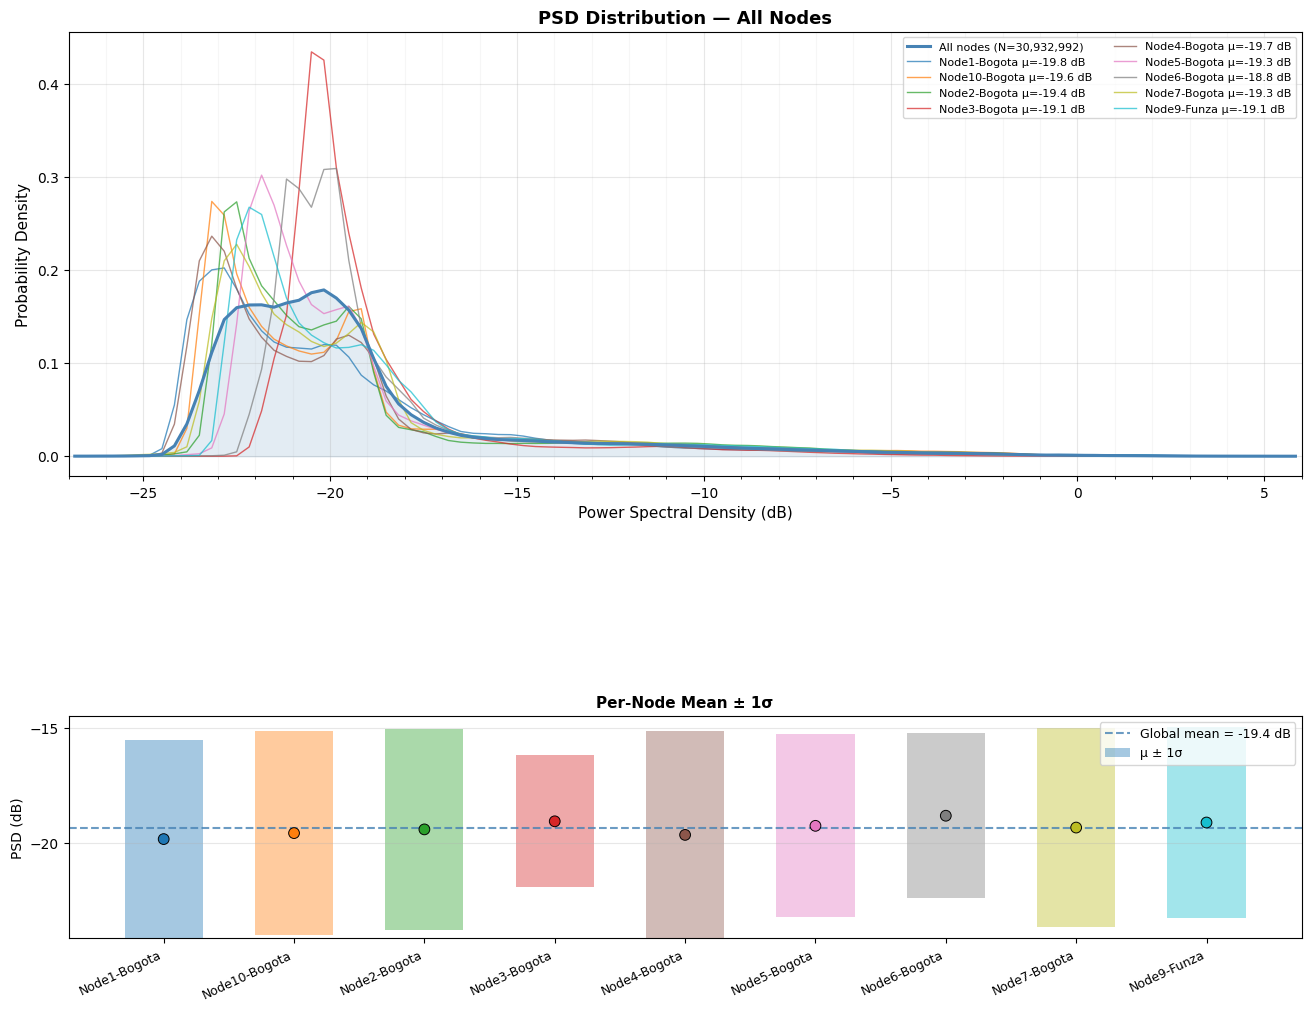


  Ranked by absolute mean cross-node similarity:
   Mean = 0.6644, Std = 0.0669
   Outlier threshold (μ - σ) = 0.5975
   Found 2 outlier(s)

  Rank   Label               Mean r       Status
  ───────────────────────────────────────────────
  1      Node7-Bogota        0.7406       ✓ High
  2      Node2-Bogota        0.7274             
  3      Node9-Funza         0.6930             
  4      Node10-Bogota       0.6887             
  5      Node1-Bogota        0.6830             
  6      Node5-Bogota        0.6790             
  7      Node4-Bogota        0.6708             
  8      Node6-Bogota        0.5784   ⚠️ Outlier
  9      Node3-Bogota        0.5190   ⚠️ Outlier


In [ ]:
# =============================================================================
# 2. Histogram ANALYSIS 
# =============================================================================

ranked_cum_corr = analyze_psd_nodes(
    datos_nodos,
    NODE_NAMES,
    NODE_LABELS,
    GLOBAL_RANGE,
    bin_edges,
    bin_centers,
    ALPHA_NODE=0.72  # Transparency for overlapping histograms
)

| Goal | Minimum Spacing | Preferred Spacing |
|------|----------------|-------------------|
| Basic diversity (omni) | 0.75 m (¼ λ @ 88 MHz) | 1.5–3.0 m (½–1 λ) |
| High isolation / low coupling | 2.8 m | 7.6 m |
| Research-grade spatial independence | 3–6 m (urban) | 10–15 m (open) |
| Bogotá–Funza network | Already satisfied (nodes are km apart) | Focus on temporal alignment & calibration |

### Cumulative Score ranking 


 Nodes ranked by Product Score:
Rank   Label                Corr         MI           Product     
----------------------------------------------------------------------
1      Node10-Bogota             0.6887      1.0000      0.8443
2      Node2-Bogota              0.7274      0.9457      0.8365
3      Node7-Bogota              0.7406      0.9072      0.8239
4      Node4-Bogota              0.6708      0.9703      0.8205
5      Node5-Bogota              0.6790      0.8753      0.7771
6      Node1-Bogota              0.6830      0.8503      0.7666
7      Node6-Bogota              0.5784      0.6154      0.5969
8      Node3-Bogota              0.5190      0.3815      0.4502
9      Node9-Funza               0.6930      0.2017      0.4473


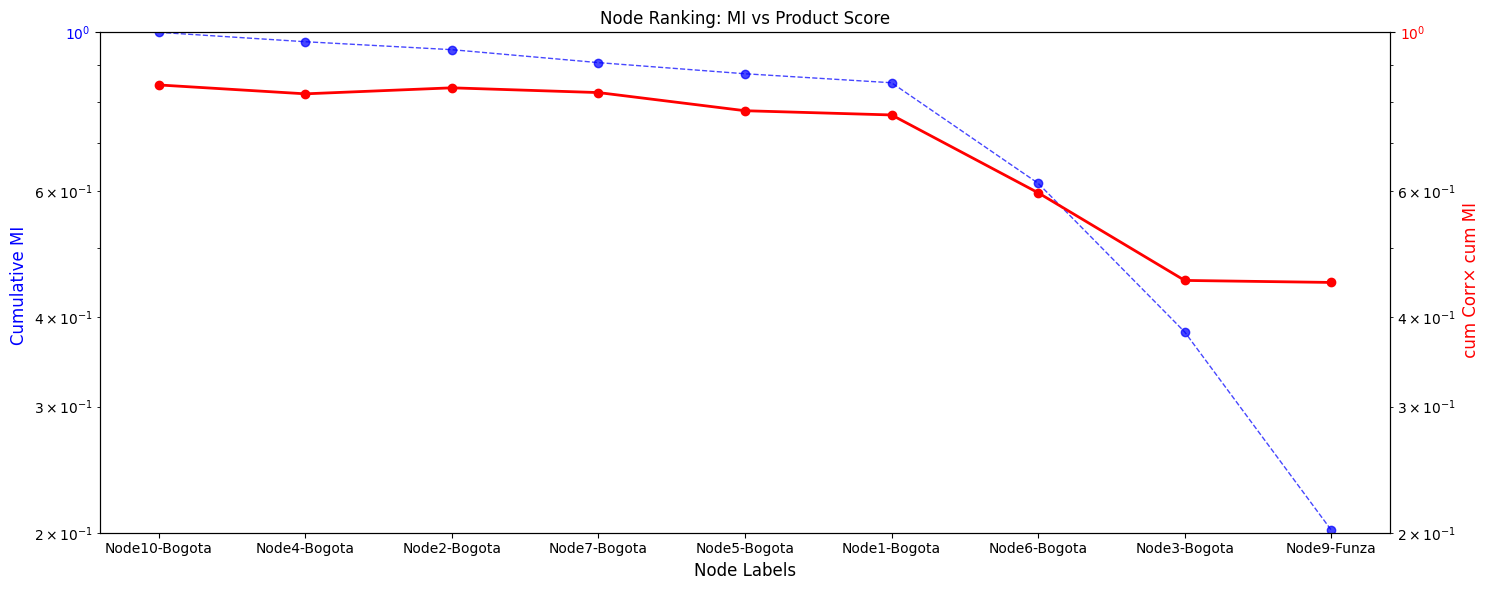

In [ ]:
# =============================================================================
# 3. Cumulative Score ranking  averaged across all campaings
# =============================================================================

# Convert pxx_node into the expected format for MI_matrix
vectors_by_node = {name: data["pxx"] for name, data in pxx_node.items()}

scores_MI, used_range = MI_matrix(
    vectors_by_node,
    bins=N_BINS,
    qrange=(1, 99),
    base=2.0,
    normalized=False,   # set True if you want NMI
)

# -----------------------
# combined cumulative  ranking over all rows
# -----------------------

Cum_scores = multiply_similarity_scores(ranked_cum_corr, scores_MI)


### Preprocessing Stage

#### *Noise floor*

bin resolution : 0.610 kHz/bin  |  GUARD_BINS: 329
Node3-Bogota: center=101.100 MHz | noise_floor=-20.43 dB | dynamic_range=40.4 dB | spike=2.33 dB | significant=False | clipping=False
Node1-Bogota: center=101.100 MHz | noise_floor=-23.18 dB | dynamic_range=34.2 dB | spike=0.47 dB | significant=False | clipping=False
Node10-Bogota: center=101.100 MHz | noise_floor=-23.02 dB | dynamic_range=29.7 dB | spike=-0.22 dB | significant=False | clipping=False
Node7-Bogota: center=101.100 MHz | noise_floor=-22.72 dB | dynamic_range=36.9 dB | spike=0.75 dB | significant=False | clipping=False
Node6-Bogota: center=101.100 MHz | noise_floor=-21.21 dB | dynamic_range=35.2 dB | spike=1.90 dB | significant=False | clipping=False
Node2-Bogota: center=101.100 MHz | noise_floor=-22.93 dB | dynamic_range=37.7 dB | spike=-0.29 dB | significant=False | clipping=False
Node4-Bogota: center=101.100 MHz | noise_floor=-23.25 dB | dynamic_range=37.6 dB | spike=0.06 dB | significant=False | clipping=False
Node5-Bo

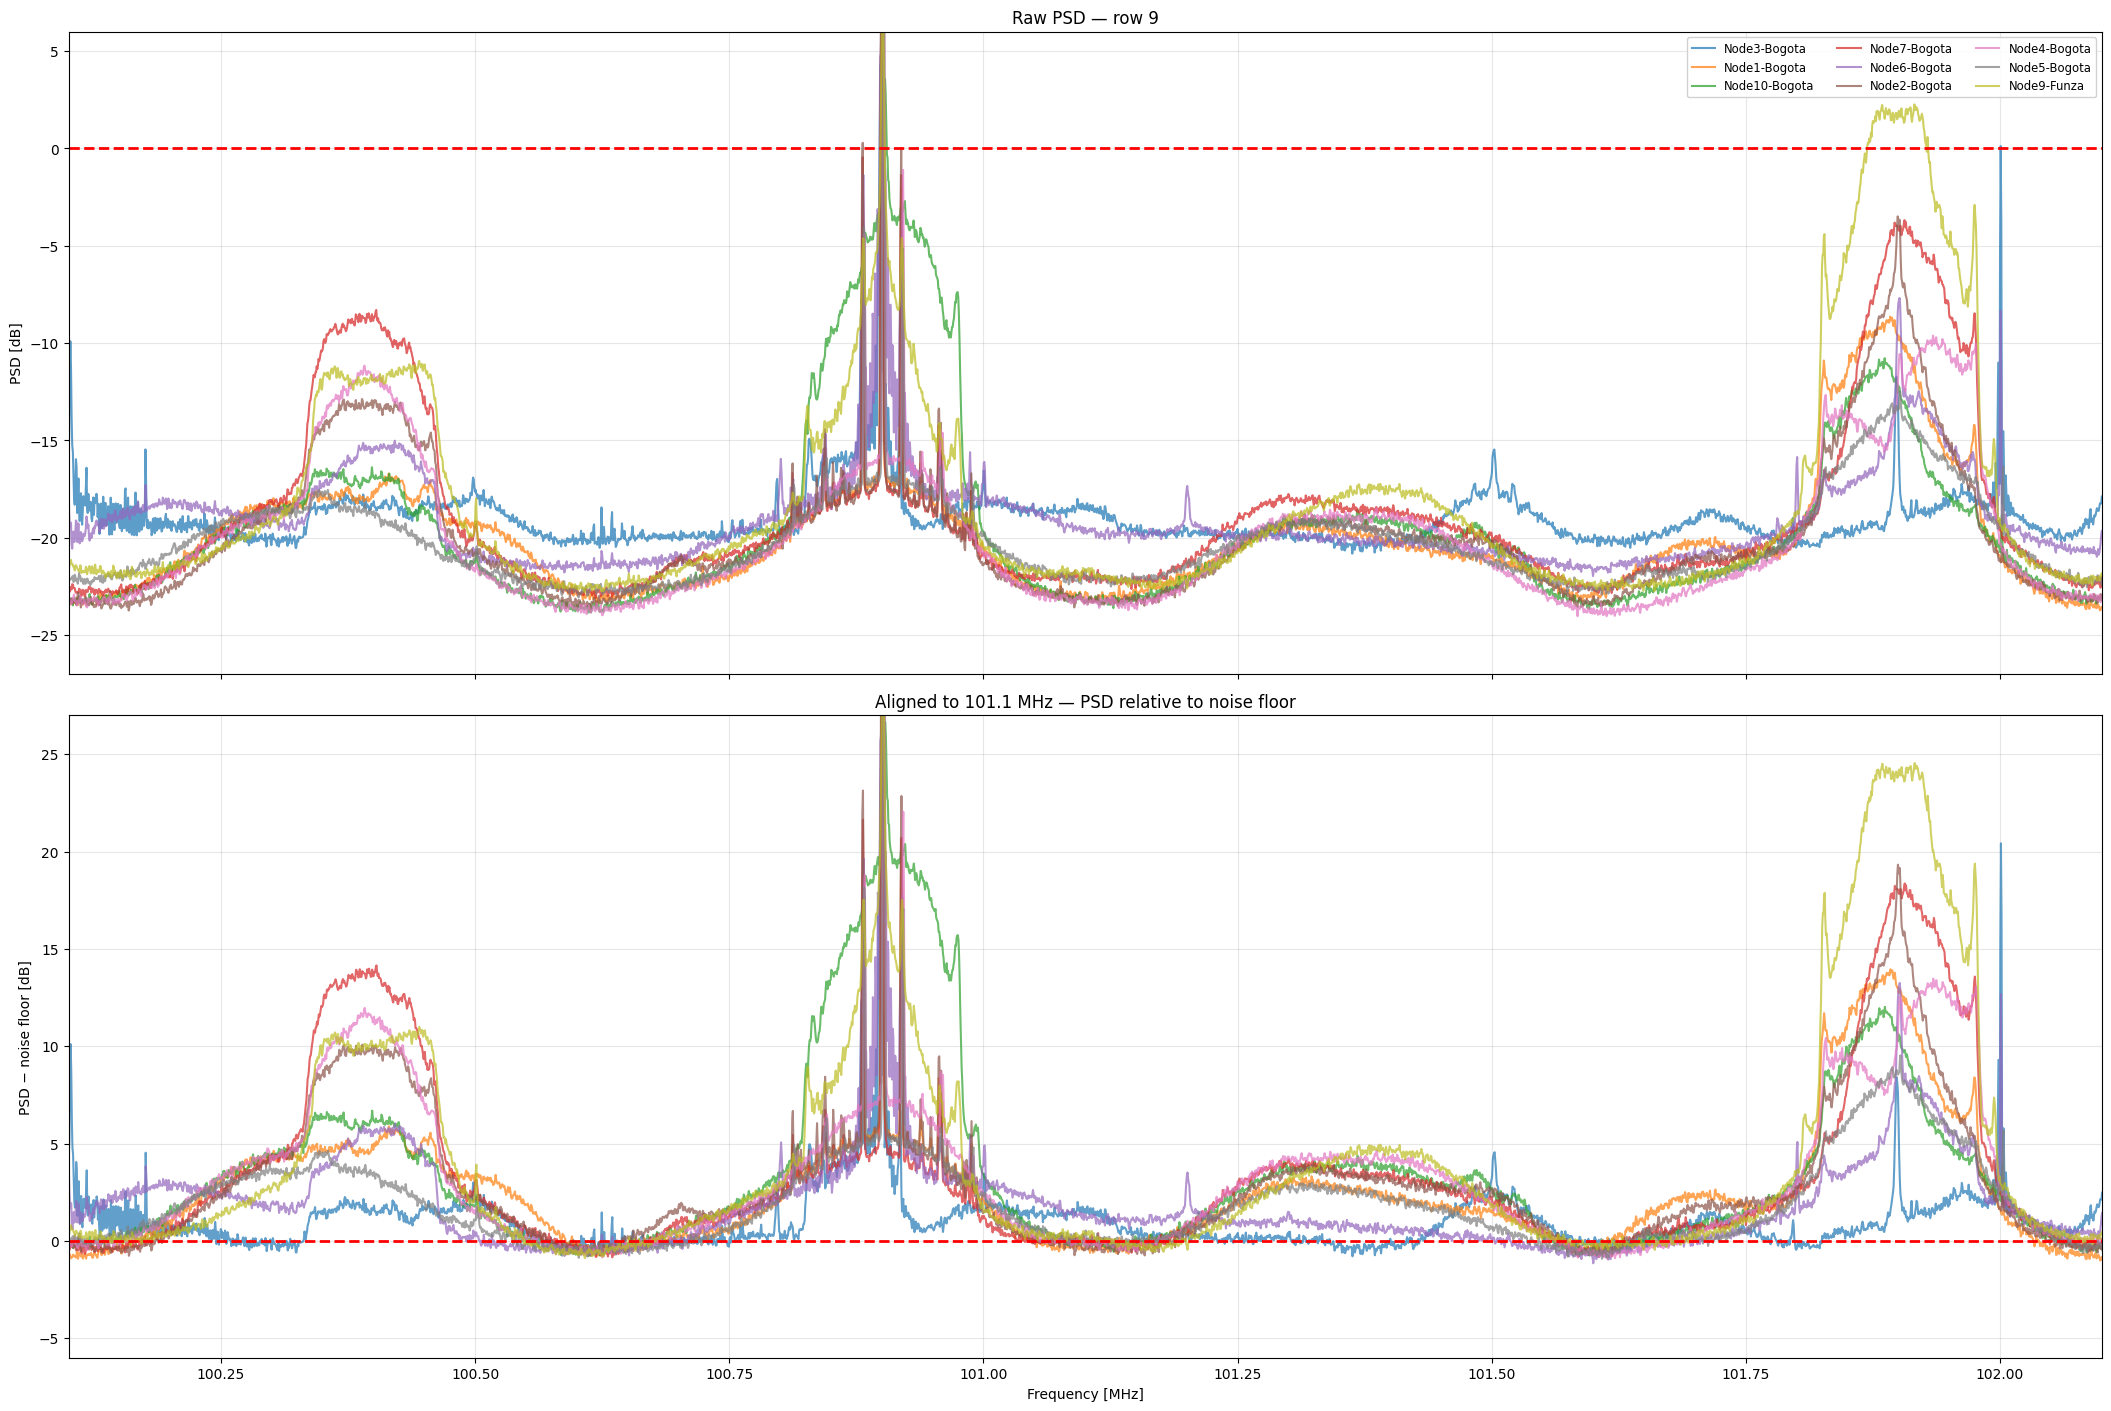

In [ ]:
fig, pxx_centered_by_node, noise_floors = plot_psd_nodes(
    datos_nodos,
    row_plot        = 9,
    pxx_len         = pxx_len,
    center_freq_mhz = 101.1,
    noise_q         = 0.15,
    ax_top_ylim     = (-27, 6),
)


✓ Created datos_nodos_ with 9 nodes
Parsing pxx across 9 nodes...
100%|██████████| 9/9 [00:07<00:00,  1.17it/s]

✓ Parsed 30,932,992 values total
⚠ 8,502 values (0.03%) fall outside GLOBAL_RANGE (-6, 27)


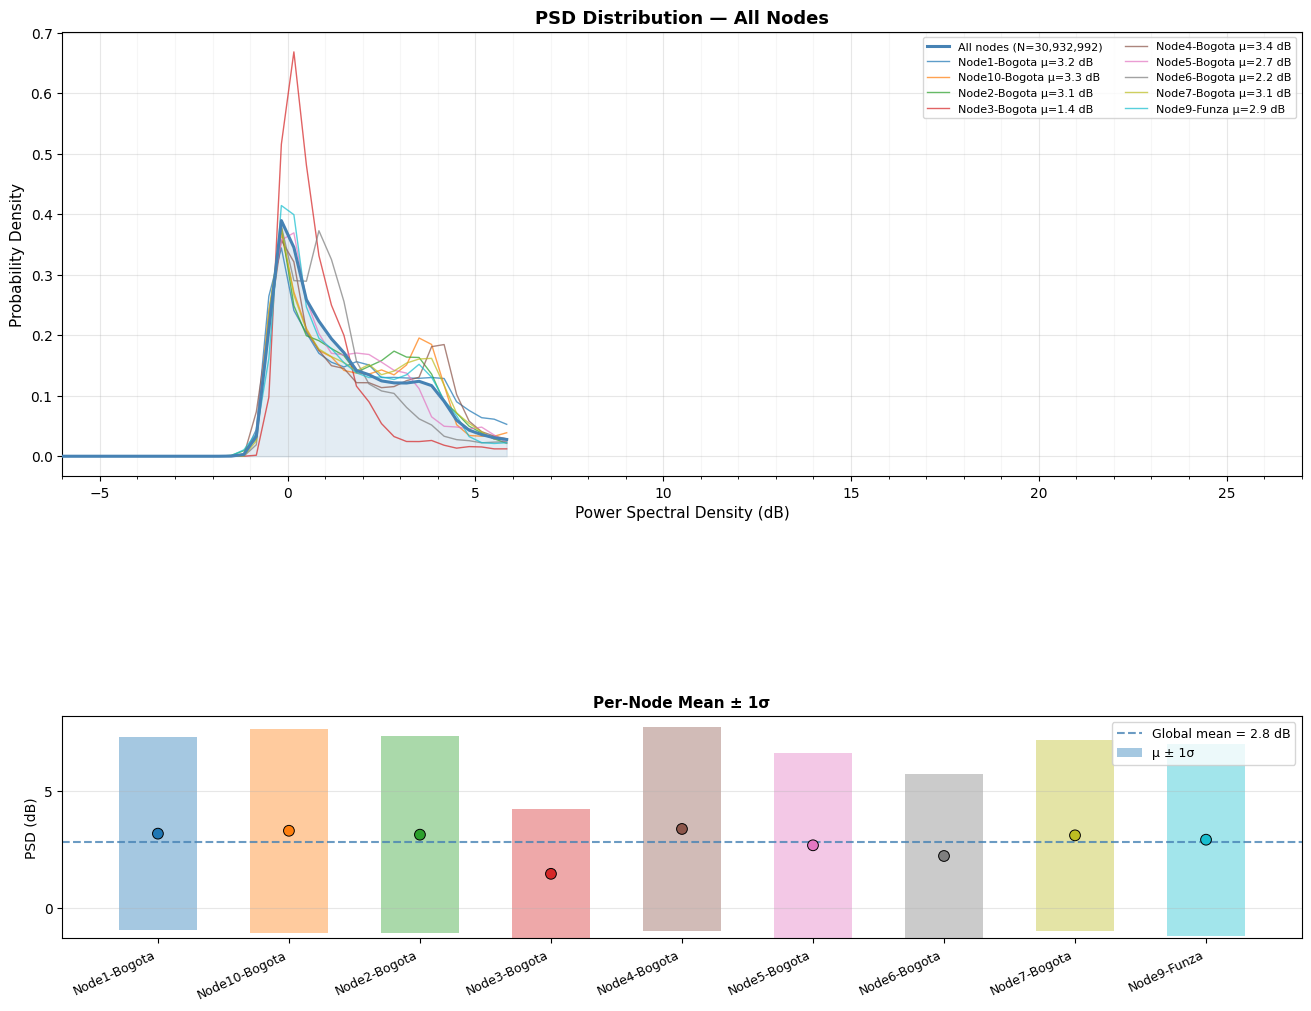


  Ranked by absolute mean cross-node similarity:
   Mean = 0.8287, Std = 0.0314
   Outlier threshold (μ - σ) = 0.7973
   Found 1 outlier(s)

  Rank   Label               Mean r       Status
  ───────────────────────────────────────────────
  1      Node9-Funza         0.8494             
  2      Node5-Bogota        0.8470             
  3      Node7-Bogota        0.8470             
  4      Node2-Bogota        0.8440             
  5      Node10-Bogota       0.8418             
  6      Node1-Bogota        0.8389             
  7      Node4-Bogota        0.8387             
  8      Node6-Bogota        0.8037             
  9      Node3-Bogota        0.7479   ⚠️ Outlier


In [ ]:
datos_nodos_ = create_centered_datos_nodos(datos_nodos, pxx_centered_by_node)
GLOBAL_RANGE = (-6, 27)  # (min_dB, max_dB)
ranked_cum_corr = analyze_psd_nodes(
    datos_nodos_,
    NODE_NAMES,
    NODE_LABELS,
    GLOBAL_RANGE,
    bin_edges,
    bin_centers,
    ALPHA_NODE=0.72  # Transparency for overlapping histograms
)


 Nodes ranked by Product Score:
Rank   Label                Corr         MI           Product     
----------------------------------------------------------------------
1      Node4-Bogota              0.8387      1.0000      0.9194
2      Node10-Bogota             0.8418      0.9824      0.9121
3      Node2-Bogota              0.8440      0.9367      0.8904
4      Node7-Bogota              0.8470      0.9311      0.8890
5      Node1-Bogota              0.8389      0.8916      0.8653
6      Node5-Bogota              0.8470      0.8488      0.8479
7      Node9-Funza               0.8494      0.8153      0.8324
8      Node6-Bogota              0.8037      0.6087      0.7062
9      Node3-Bogota              0.7479      0.3350      0.5415


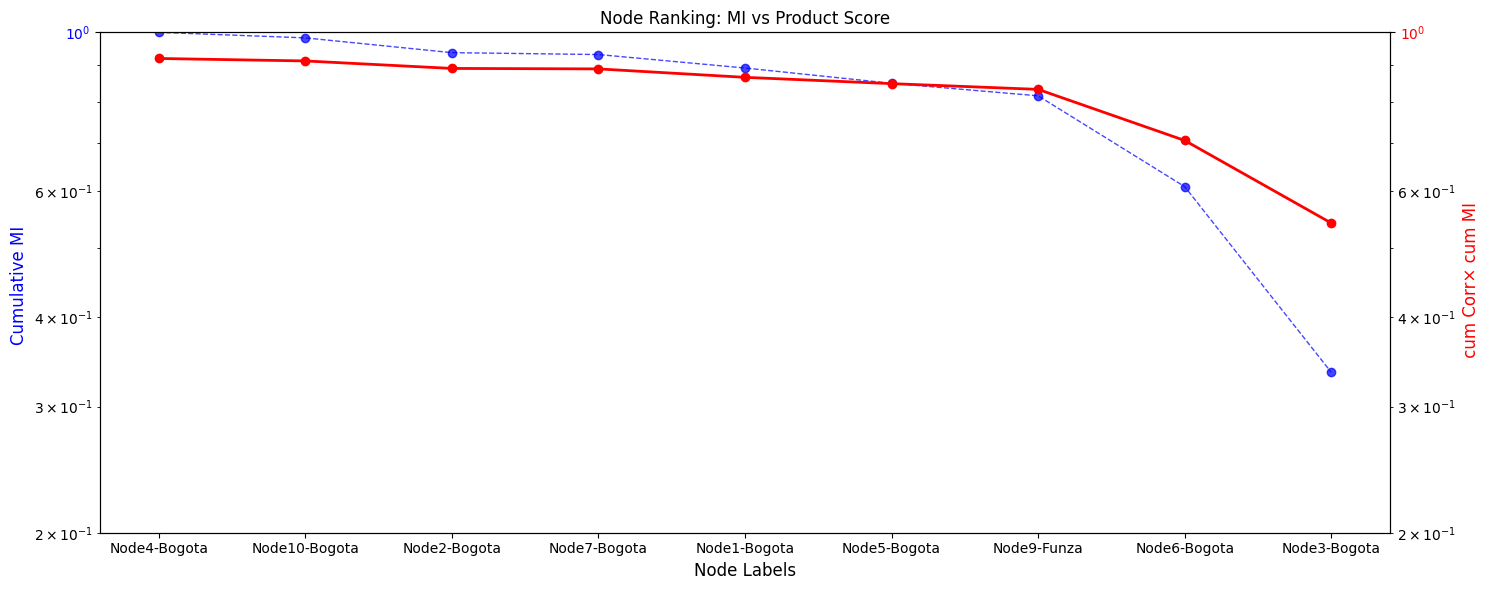

In [ ]:

scores_MI, used_range = MI_matrix(
    pxx_centered_by_node,
    bins=N_BINS,
    qrange=(1, 99),
    base=2.0,
    normalized=False,   # set True if you want NMI
)

# -----------------------
# combined cumulative  ranking over all rows
# -----------------------

Cum_scores = multiply_similarity_scores(ranked_cum_corr, scores_MI)

### Spectral Parameter Estimation Quality

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c4818a93-f2bf-4892-b7a2-47816cd4c47d' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>